# Canonical MO-BIO multi-objective workflow

This notebook is the isolated canonical counterpart to `CandidateParameterSetsBio_MultiObjectiveTPE.ipynb`.

It follows the same core sequence—review, prepare a study, generate candidates, register results, and write ROMS inputs—but uses canonical objectives recalculated from observation/model pairs. It never reads or writes the legacy Optuna database. Keep `RUN_MODE = "review"` unless you deliberately intend a state-changing action.

Scientific definition and recovery instructions are in `CANONICAL_MO_BIO_GUIDE.md`.

## Checklist before using this notebook

Use this as a working checklist. Keep `RUN_MODE = "review"` while inspecting data or making decisions; the other modes can create a study, trials, or input files.

### Before the first canonical study

- [x] Choose the new tunable parameters in `canonical_parameter_priors.csv`: change each `review` decision to `active`, `fixed`, or `reserve`, and confirm every fixed value. Historical trials may retain parameters and values outside this new search space.
- [x] Confirm `OBJECTIVE_VERSION` in `canonical_mo_bio.py` and `STUDY_NAME` below. Use a new study name/database if the objective definition changes.
- [x] New-candidate biological advection is forced and validated as U3/C4 for all 15 biological tracers. `CACO3` and `USE_MOCSY` are excluded from the current search; their dependency must be enforced before either is activated in a future study.
- [x] Open the notebook in the MO-BIO Python environment that has Optuna and the project dependencies installed.
- [x] Run once in `review` mode with `DATA_LOAD_MODE = "refresh_and_save"`; inspect refresh failures, invalid objectives, year coverage, CPP categories, and advection-policy summaries.
- [ ] Set `RUN_MODE = "prepare_study"` to create the isolated canonical database and import eligible completed historical runs. Check the reported imported, skipped, and failed counts.

### For each new candidate batch

- [ ] Return to `review` and inspect the Pareto front, representative runs, parameter distributions, categorical diagnostics, model-year matches, and continuation recommendations.
- [ ] Set `N_CANDIDATES`, `CANDIDATE_TARGET_YEAR`, initialization policy/run, and a unique `CANDIDATE_BATCH_ID`.
- [ ] Use `generate_candidates`, inspect the candidate table, then use `write_inputs` only after approving the candidates.
- [ ] Verify temperature and salinity use U3/C4 in the physical model configuration; this biological input writer controls only biological tracers.
- [ ] Submit the model runs and record them in the usual master run list.

### When model runs finish

- [ ] Add or update the run records, cost files, and station files, then use `refresh_and_save` to rebuild the independent canonical cache.
- [ ] Inspect strict observation/model coverage failures before registering results.
- [ ] Use `register_results` to attach valid canonical objectives to their waiting Optuna trials, then return to `review`.

### For continuation runs

- [ ] Review the continuation recommendations and choose source run names in `CONTINUATION_SOURCES_TO_PLAN`.
- [ ] Copy the displayed planned rows into the `MO-BIO Year Transitions` sheet of `FileNames.xlsx`, retaining the `MO-BIO-CANONICAL` tag, and save the workbook.
- [ ] Use `write_continuation_inputs`, verify biological U3/C4 and the separate physical U3/C4 setup, and update the transition status as the run progresses.

> Backcast mode is intentionally deferred. The legacy MO-BIO notebook and database remain separate and unchanged.

In [1]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from IPython.display import display

import canonical_mo_bio as cmo
import canonical_plotting as cplot
import candidate_parameter_utils as cpu

plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})
pd.set_option("display.max_rows", 120)

## 1. Operating controls

In [2]:
# USER INPUT: choose one explicit mode.
# review | prepare_study | generate_candidates | register_results | write_inputs | write_continuation_inputs
RUN_MODE = "prepare_study"
DATA_LOAD_MODE = "refresh_and_save"  # cache | refresh | refresh_and_save
N_CANDIDATES = 4
RANDOM_SEED = 42
CANDIDATE_TARGET_YEAR = 2005
CANDIDATE_INITIALIZATION_POLICY = "common_initial_condition"
CANDIDATE_INITIALIZATION_RUN = None
CANDIDATE_BATCH_ID = "CANONICAL_2005_BATCH_01"
SAVE_AUDIT_OUTPUTS = True
NEAR_PARETO_RANK = 3
TRIAL_BUDGET = 30
STRONG_CONFOUNDING_THRESHOLD = 0.80
RUN_NONLINEAR_SCREENING = True
N_PARAMETER_DISTRIBUTIONS_TO_PLOT = 12
FOCUSED_PARAMETER_TO_INSPECT = "wsd"  # Set to None to omit the focused plot.
COMPONENT_HEATMAP_MAX_RUNS = 40
MAX_LINKED_TRAJECTORY_GROUPS = 8
STATION_DIAGNOSTIC_RUNS = []  # Empty uses the representative runs selected below.
INACTIVE_PARAMETERS_TO_DIAGNOSE = [
    "amaxs1", "amaxs2", "bUmax_nspc0", "bUmax_nspc1", "bnit",
    "bgamma4", "bgamma7", "bgamma3", "gmaxs1", "gmaxs2",
    "akno3s1", "akno3s2",
]

PROJECT_DIR = Path.cwd()
OPT_DIR = Path(os.environ.get("ROMS_OPT_DIR", Path.home() / "Desktop" / "Optimization"))
COST_DIR = Path(os.environ.get("ROMS_COST_DIR", Path.home() / "Desktop" / "COST_FILES"))
OUTPUT_ROOT = OPT_DIR / "MO-BIO-CANONICAL"
OUTPUT_PATHS = cmo.CanonicalOutputPaths(OUTPUT_ROOT)
cmo.ensure_output_layout(OUTPUT_PATHS)

FILE_LIST = OPT_DIR / "FileNames.xlsx"
RUN_INVENTORY_SHEET = "Master"
PARAMETER_LIST = OPT_DIR / "ParameterList copy.csv"
LEGACY_CORRECTIONS_FILE = OPT_DIR / "MO-BIO" / "quality_control" / "data_corrections.csv"
PARAMETER_PRIORS_FILE = PROJECT_DIR / "canonical_parameter_priors.csv"
MATCH_PRIORS_FILE = PROJECT_DIR / "parameter_priors.csv"  # Full legacy inventory for exact cross-year signatures.
COMPONENTS_FILE = PROJECT_DIR / "canonical_mo_bio_components.csv"
STUDY_NAME = cmo.DEFAULT_STUDY_NAME

OPTICS_TEMPLATE = Path.home() / "Desktop" / "LHS" / "bio_UMAINE15_sediment_optics_LHS1.in"
SEDIMENT_TEMPLATE = Path.home() / "Desktop" / "LHS" / "bio_UMAINE15_sedmodel_LHS1.in"
REMOTE_SEDIMENT_DIRECTORY = "/home/abaskind_uri_edu/ROMS_forcing_files/input_files/OPTUNA"
BASELINE_RUN_NAME = "OPTUNA_66"
OVERWRITE_CANDIDATE_FILES = False
OVERWRITE_CONTINUATION_FILES = False

# USER INPUT: continuation planning. Add selected recommendations by run name.
YEAR_TRANSITION_SHEET = "MO-BIO Year Transitions"
CONTINUATION_SOURCE_YEAR = 2005
CONTINUATION_TARGET_YEAR = 2006
CONTINUATION_SOURCES_TO_PLAN = []
CONTINUATION_LEDGER_TAG = "MO-BIO-CANONICAL"

BIO_NL_TNU2_PARAMETER = "nl_tnu2_tracer9"
BIO_ADVECTION_PARAMETER = "tracer9_advection_scheme"
CANONICAL_BIO_ADVECTION_CATEGORY = "Upstream3_Centered4"
BIOLOGICAL_TRACER_COUNT = 15
BIO_ADVECTION_SCHEMES = {
    "Upstream3_Centered4": ("Upstream3", "Centered4"),
    "HSIMT": ("HSIMT", "HSIMT"),
    "Akima4": ("Akima4", "Akima4"),
    "MPDATA": ("MPDATA", "MPDATA"),
}
ADVECTION_INPUT_CODES = {
    "Upstream3": "U3", "Centered4": "C4", "Akima4": "A4",
    "MPDATA": "MPDATA", "HSIMT": "HSIMT",
}

valid_modes = {"review", "prepare_study", "generate_candidates", "register_results", "write_inputs", "write_continuation_inputs"}
if RUN_MODE not in valid_modes:
    raise ValueError(f"RUN_MODE must be one of {sorted(valid_modes)}")
if CANDIDATE_INITIALIZATION_POLICY not in {"common_initial_condition", "common_anchor"}:
    raise ValueError("Unknown candidate initialization policy")
if CANDIDATE_INITIALIZATION_POLICY == "common_initial_condition" and CANDIDATE_TARGET_YEAR != 2005:
    raise ValueError("common_initial_condition is supported only for 2005")
if CANDIDATE_INITIALIZATION_POLICY == "common_anchor" and not CANDIDATE_INITIALIZATION_RUN:
    raise ValueError("common_anchor requires CANDIDATE_INITIALIZATION_RUN")

display(pd.DataFrame([
    {"Setting": "Run mode", "Value": RUN_MODE},
    {"Setting": "Data load mode", "Value": DATA_LOAD_MODE},
    {"Setting": "Objective version", "Value": cmo.OBJECTIVE_VERSION},
    {"Setting": "Study", "Value": STUDY_NAME},
    {"Setting": "Output root", "Value": str(OUTPUT_ROOT)},
    {"Setting": "Database", "Value": str(OUTPUT_PATHS.study_database)},
    {"Setting": "Candidate target year", "Value": CANDIDATE_TARGET_YEAR},
]))
DF_year_transition_plan = cpu.load_year_transition_plan(FILE_LIST, sheet_name=YEAR_TRANSITION_SHEET)


,Setting,Value
0,Run mode,prepare_study
1,Data load mode,refresh_and_save
2,Objective version,canonical_mo_bio_ward_obs_error_v1
3,Study,model_calibration_bio_canonical_v1
4,Output root,/Users/akbaskind/Desktop/Optimization/MO-BIO-C...
5,Database,/Users/akbaskind/Desktop/Optimization/MO-BIO-C...
6,Candidate target year,2005


## 2. Recalculate and review canonical objectives

This step is safe in every mode. The canonical cache is independent of the legacy MO-BIO cache. Use `refresh` to inspect a source rebuild without replacing it, and `refresh_and_save` to atomically replace it.

In [3]:
DF_archive, DF_refreshed_components, DF_refresh_failures, data_source_description = cmo.load_or_refresh_canonical_cache(
    mode=DATA_LOAD_MODE,
    inventory_file=FILE_LIST,
    inventory_sheet=RUN_INVENTORY_SHEET,
    parameter_list_file=PARAMETER_LIST,
    cost_root=COST_DIR,
    components_file=COMPONENTS_FILE,
    output_paths=OUTPUT_PATHS,
)
print(f"Data source: {data_source_description}")
source_inventory = cpu.normalize_run_inventory_names(
    pd.read_excel(FILE_LIST, sheet_name=RUN_INVENTORY_SHEET)
    .loc[:, ["Run Name", "Cost File", "Station File"]].dropna()
)
source_files = [
    COST_DIR / str(name)
    for column in ["Cost File", "Station File"]
    for name in source_inventory[column].dropna()
]
cache_freshness = cpu.cache_status(OUTPUT_PATHS.archive_file, source_files)
cache_inventory_missing = sorted(set(source_inventory["Run Name"]) - set(DF_archive["Run Name"]))
display(pd.DataFrame([
    {"Check": "Cache modified UTC", "Result": cache_freshness.cache_modified_utc},
    {"Check": "Source files newer than cache", "Result": len(cache_freshness.newer_source_files)},
    {"Check": "Missing listed source files", "Result": len(cache_freshness.missing_source_files)},
    {"Check": "Inventory runs absent from cache", "Result": len(cache_inventory_missing)},
]))
if DATA_LOAD_MODE == "cache" and cache_freshness.newer_source_files:
    print("Source files are newer than the canonical cache; consider refresh_and_save.")
if DATA_LOAD_MODE == "cache":
    DF_refreshed_components = pd.read_csv(OUTPUT_PATHS.component_metrics_file)
    DF_refresh_failures = pd.read_csv(OUTPUT_PATHS.failures_file)

# Exact cross-year signatures continue to use the full legacy parameter inventory.
DF_archive = cpu.add_biological_parameter_match_groups(
    DF_archive, cpu.load_parameter_priors(MATCH_PRIORS_FILE)
)
if DATA_LOAD_MODE == "refresh_and_save":
    cpu.atomic_write_csv(DF_archive, OUTPUT_PATHS.archive_file, index=False)

DF_priors = cpu.load_parameter_priors(PARAMETER_PRIORS_FILE)
DF_detected_issues = cpu.detect_data_quality_issues(DF_archive, DF_priors)
DF_corrections = (
    cpu.load_corrections(LEGACY_CORRECTIONS_FILE)
    if LEGACY_CORRECTIONS_FILE.is_file()
    else pd.DataFrame(columns=cpu.CORRECTION_COLUMNS)
)
DF_corrected, DF_quality_issues, DF_correction_audit = cpu.apply_corrections(
    DF_archive, DF_detected_issues, DF_corrections
)
objective_columns = list(cmo.OBJECTIVE_COLUMNS)
finite = np.isfinite(DF_corrected[objective_columns].apply(pd.to_numeric, errors="coerce")).all(axis=1)
finite &= DF_corrected["Objective Status"].eq("valid")
DF_analysis = cpu.add_pareto_columns(DF_corrected.loc[finite].reset_index(drop=True), objective_columns, near_rank=NEAR_PARETO_RANK)

print(f"Canonical analysis-ready runs: {len(DF_analysis)} of {len(DF_archive)} inventory rows")
print(f"Exact Pareto runs: {int(DF_analysis['Pareto Optimal'].sum())}")
display(DF_analysis[["Run Name", *objective_columns, "dstart_year", "Pareto Rank"]]
        .sort_values(["Pareto Rank", objective_columns[0]]).head(30))

Data source: fresh source files; canonical cache replaced


,Check,Result
0,Cache modified UTC,2026-10-04T18:41:31+00:00
1,Source files newer than cache,0
2,Missing listed source files,1
3,Inventory runs absent from cache,0


Canonical analysis-ready runs: 124 of 131 inventory rows
Exact Pareto runs: 5


,Run Name,Canonical Cost,Canonical Bottom pH Objective,dstart_year,Pareto Rank
116,D13_2005,18.521351,0.892500,2005.0,0
106,OPTUNA_66,20.762798,0.744813,2005.0,0
117,D13_2006,22.504084,0.739013,2006.0,0
120,OPTUNA_66_2006,23.975993,0.721782,2006.0,0
110,OPTUNA_76,24.711967,0.648309,2005.0,0
107,OPTUNA_67,20.274200,0.996504,2005.0,1
108,OPTUNA_74,20.529873,0.927192,2005.0,1
105,OPTUNA_65,20.792638,0.853359,2005.0,1
37,D13,21.946047,0.838987,2005.0,1
32,D12,23.127577,0.838984,2005.0,1


Spearman relationship between canonical objectives:


,Canonical Cost,Canonical Bottom pH Objective
Canonical Cost,1.000000,0.549209
Canonical Bottom pH Objective,0.549209,1.000000


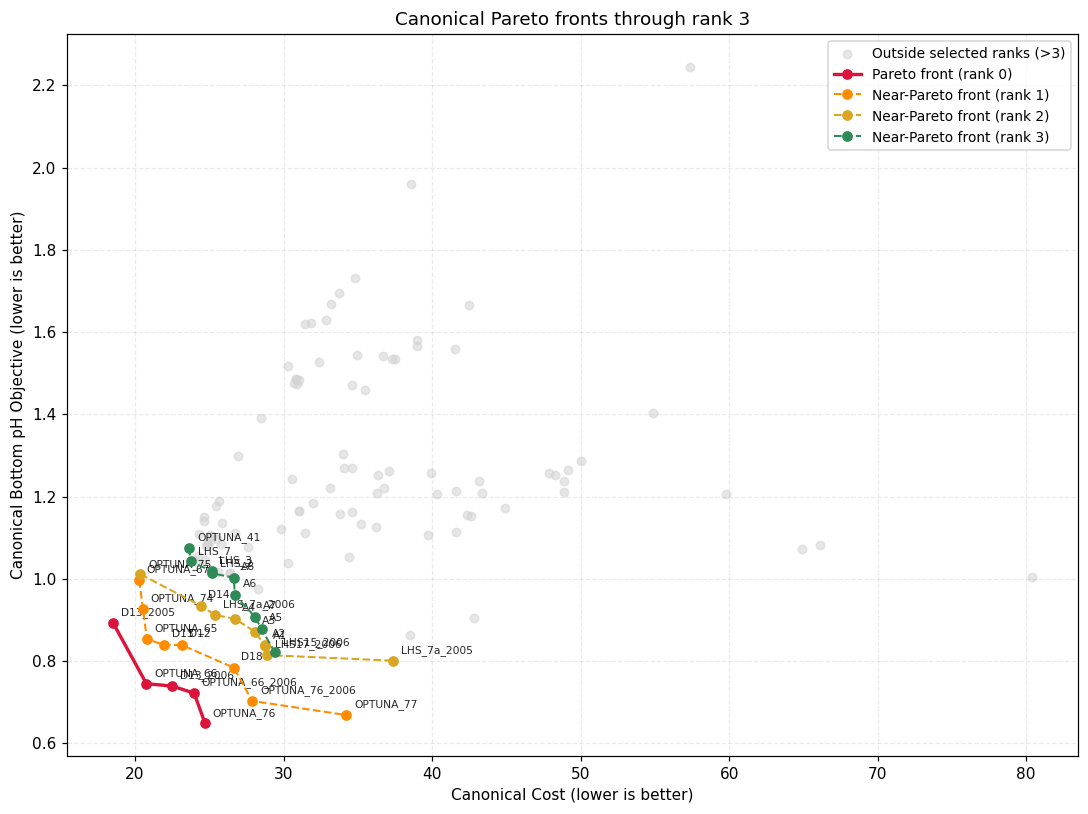

In [4]:
objective_relationship = DF_analysis[objective_columns].corr(method="spearman")
print("Spearman relationship between canonical objectives:")
display(objective_relationship)
cplot.plot_pareto_fronts(
    DF_analysis, objective_columns, maximum_rank=NEAR_PARETO_RANK,
    output=(OUTPUT_PATHS.figure_directory / "canonical_pareto_fronts.png")
    if SAVE_AUDIT_OUTPUTS else None,
)

## 3. Representative runs and canonical components

Representative selections preserve the two-objective interpretation: the best total canonical cost, the best bottom-pH normalized RMSE, and the balanced point on the exact Pareto front. Component figures show why those runs score well or poorly. The ranked heatmap emphasizes the leading runs; the all-run heatmap provides a complete archive view.

,Selection Role,Run Name,Canonical Cost,Canonical Bottom pH Objective,dstart_year,Pareto Rank,All Tracer Advection Policy Compliant
0,Best holistic cost,D13_2005,18.521351,0.892500,2005.0,0,False
1,Best Bottom pH,OPTUNA_76,24.711967,0.648309,2005.0,0,True
2,Balanced normalized compromise,OPTUNA_66,20.762798,0.744813,2005.0,0,True


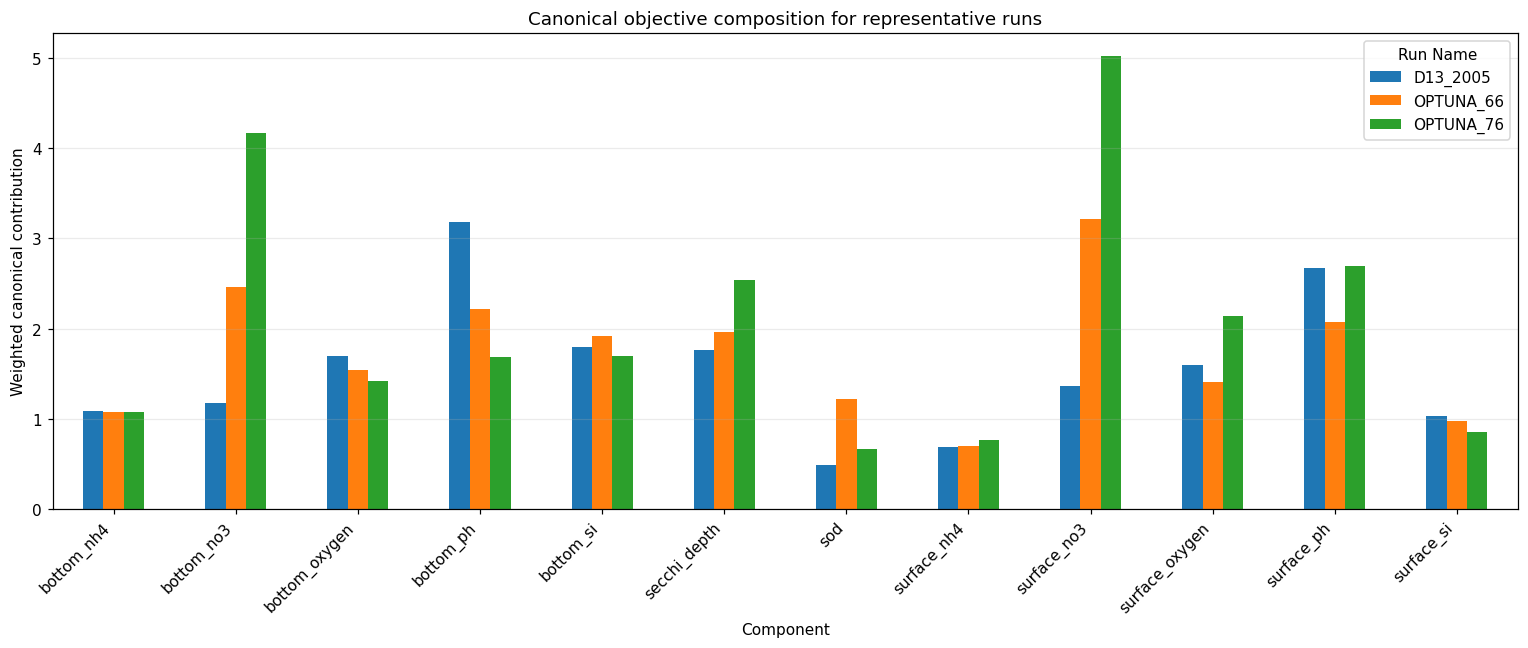

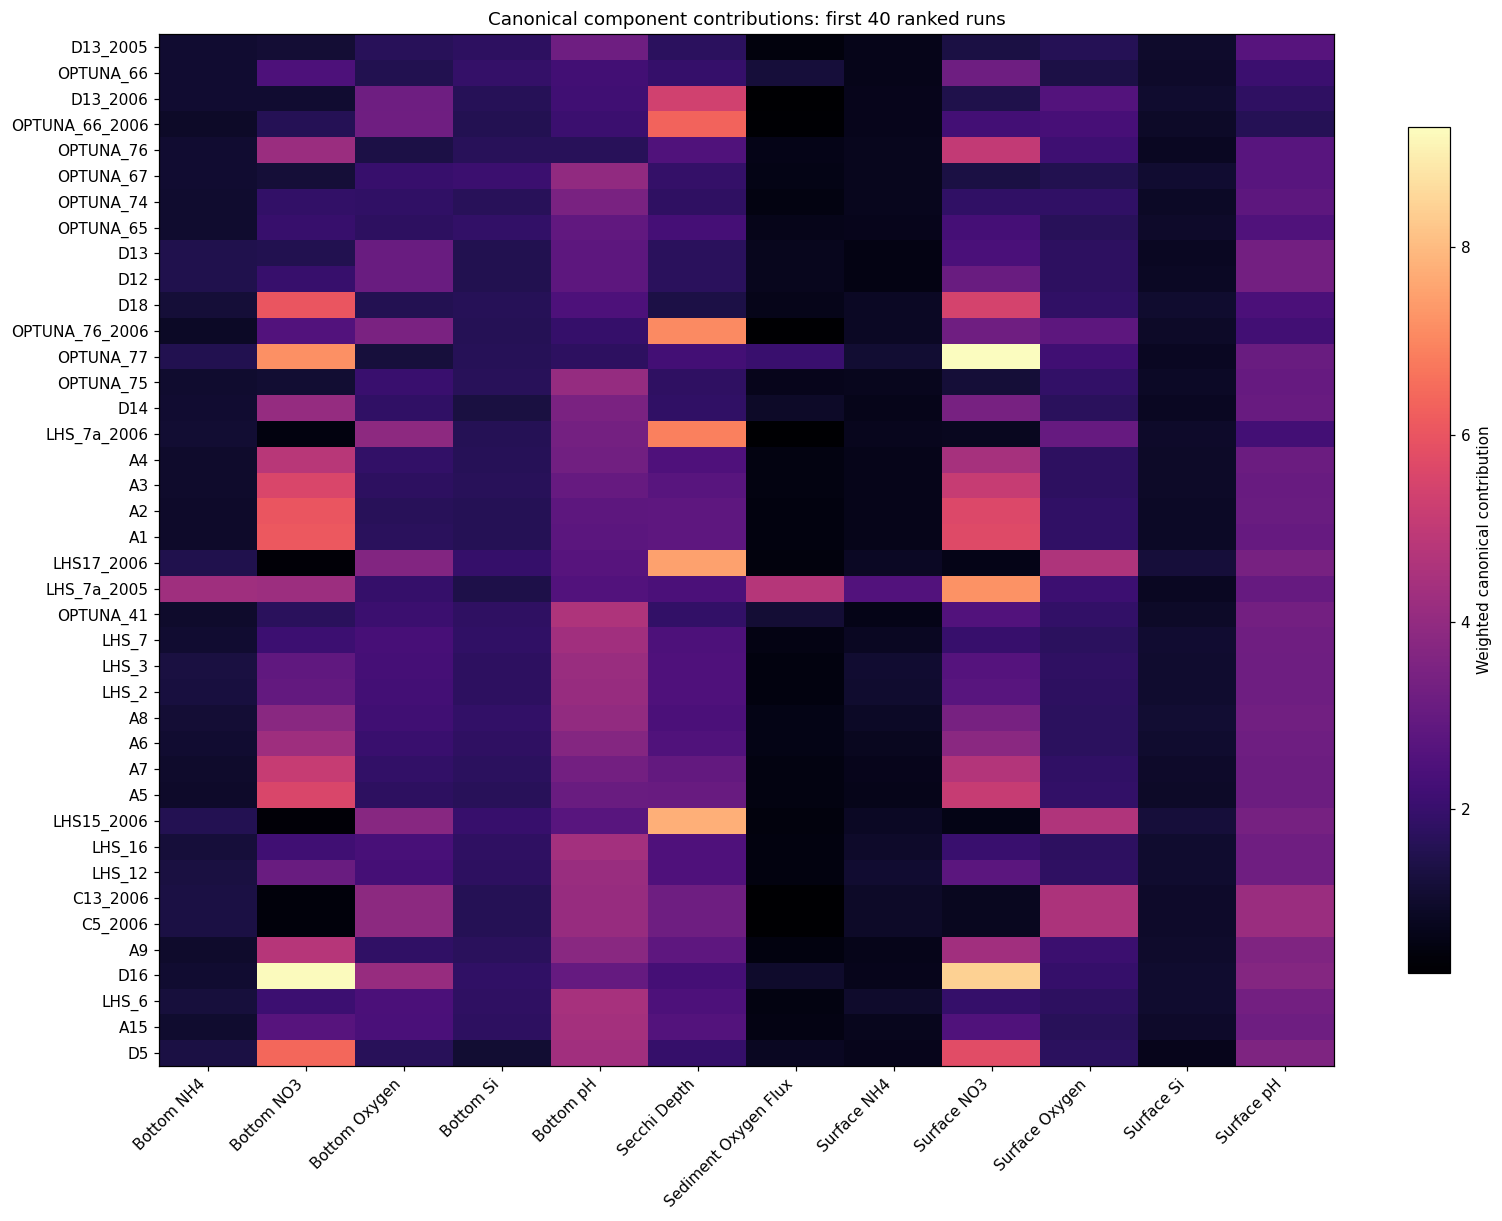

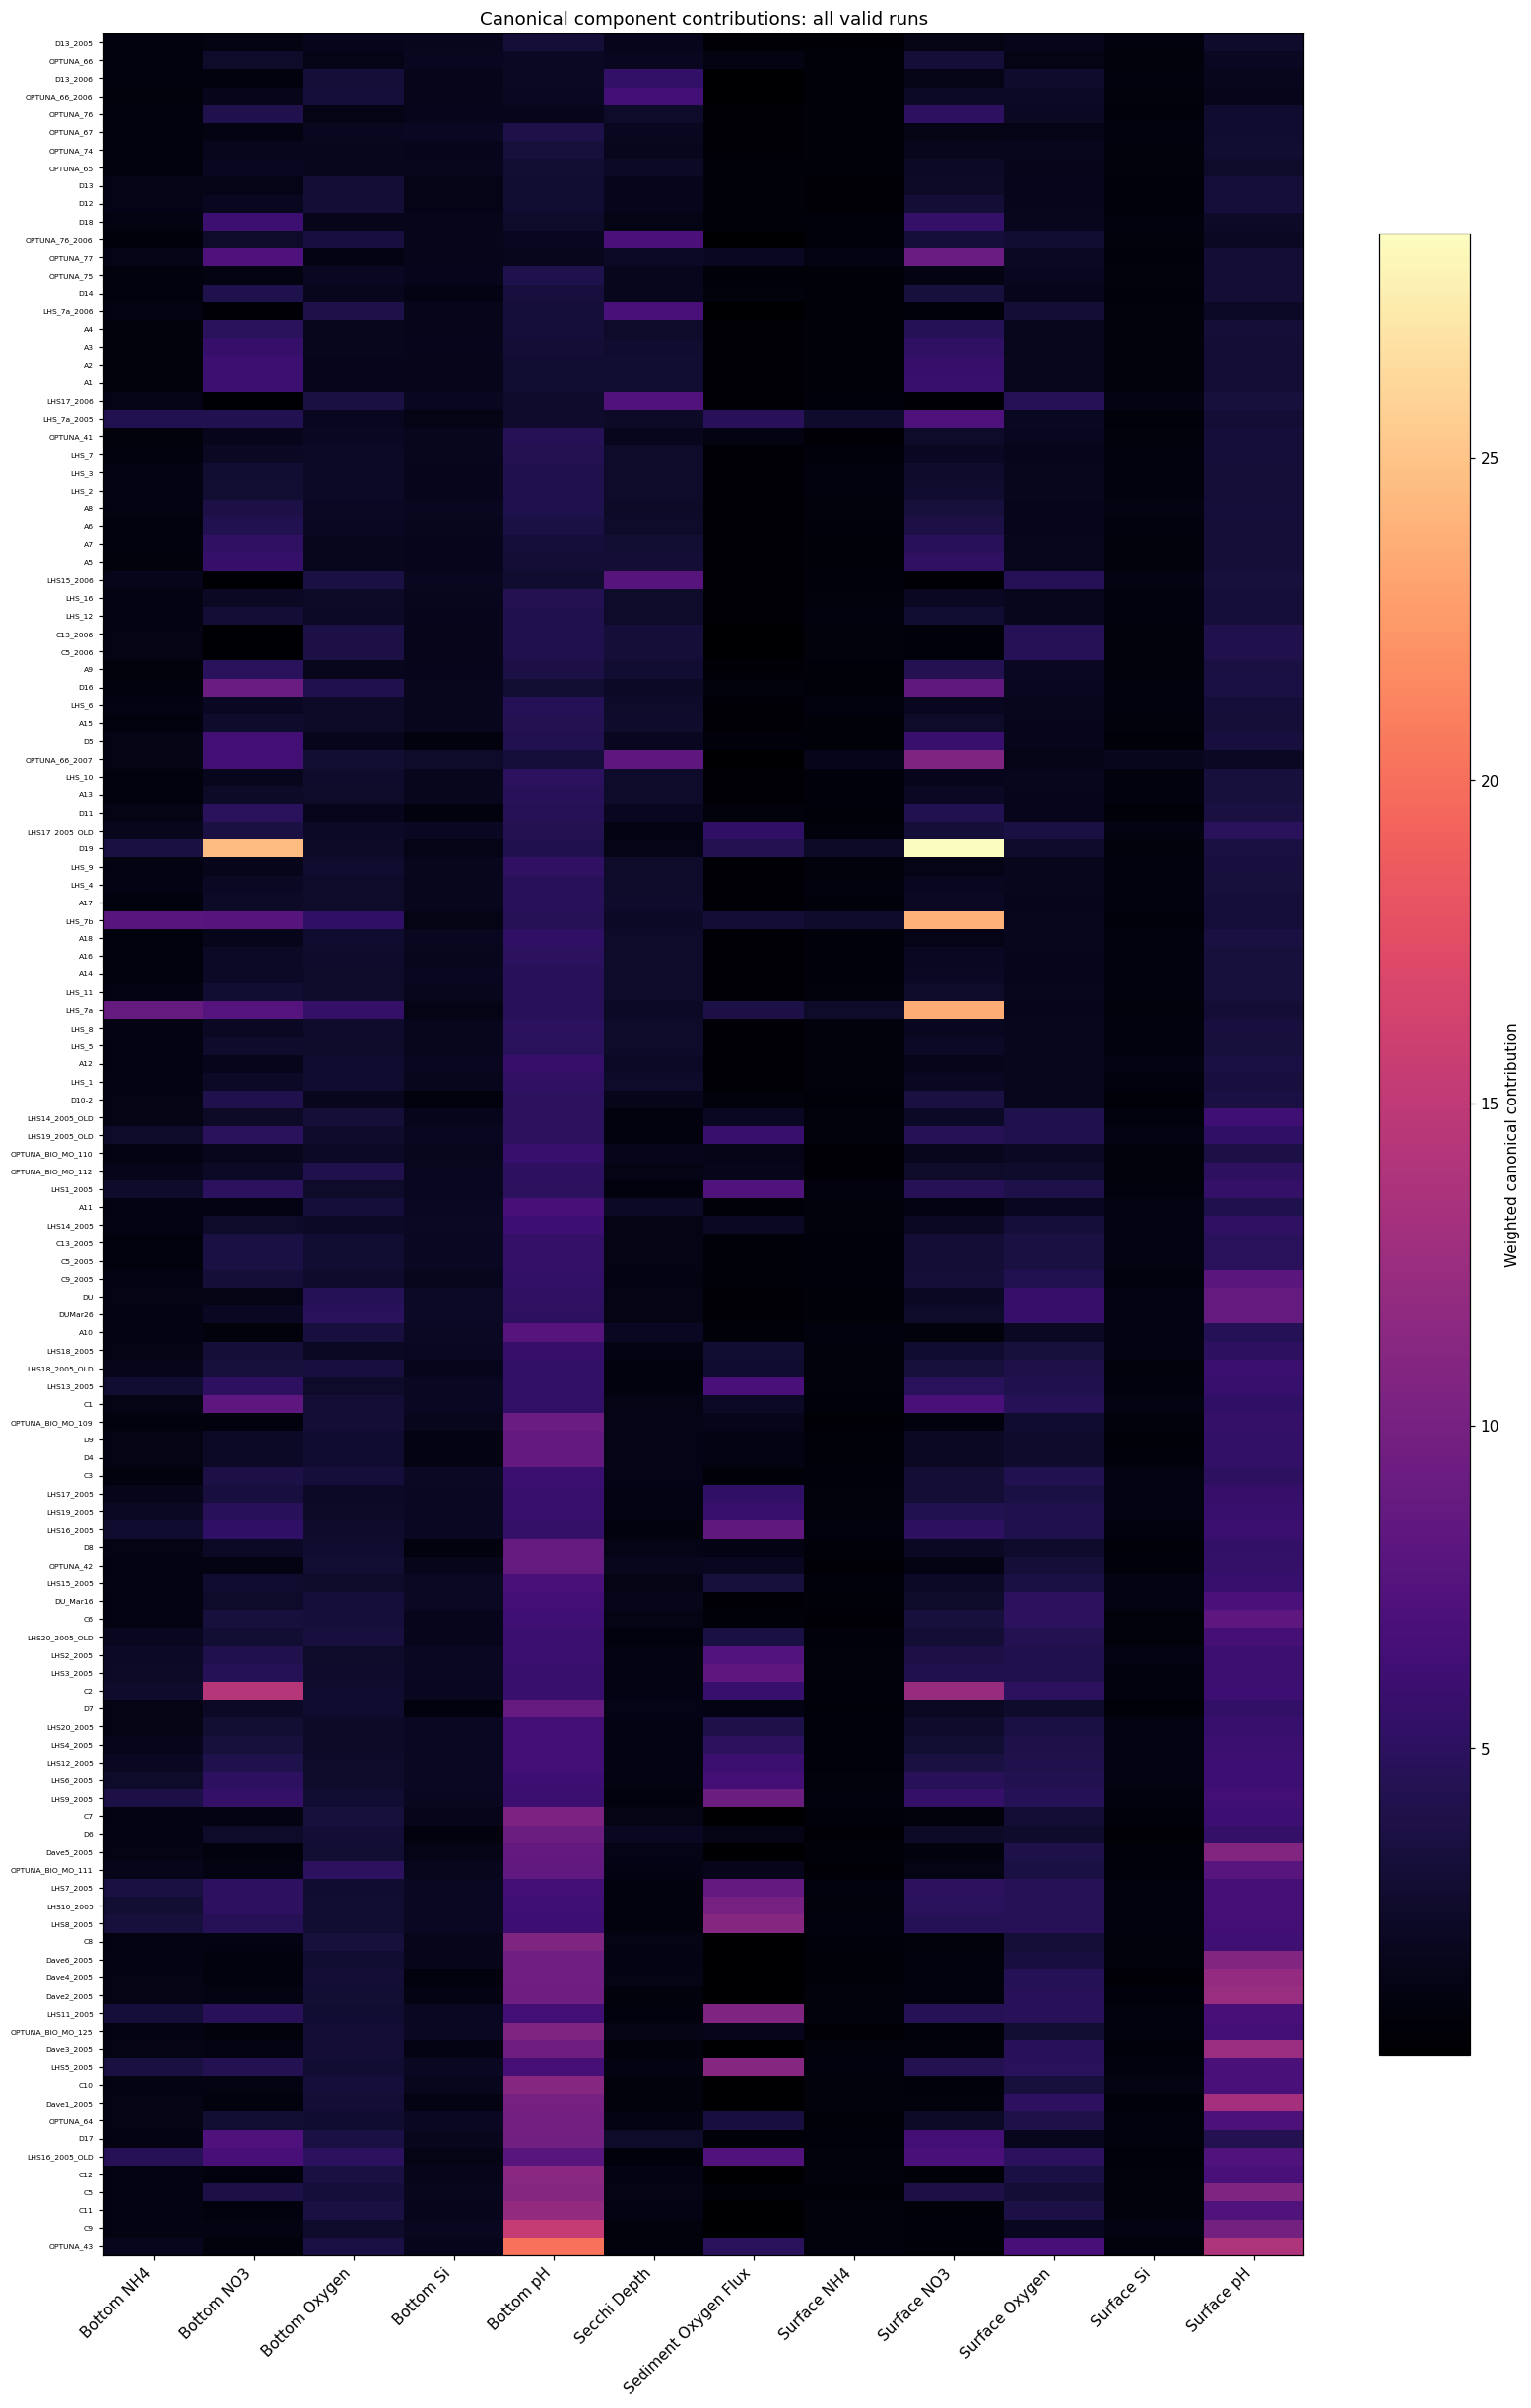

In [5]:
DF_representatives = cpu.select_representative_candidates(
    DF_analysis,
    cost_column=objective_columns[0],
    bottom_ph_column=objective_columns[1],
)
display(DF_representatives[[
    "Selection Role", "Run Name", *objective_columns,
    "dstart_year", "Pareto Rank", "All Tracer Advection Policy Compliant",
]])

DF_components = DF_refreshed_components.copy()
representative_names = DF_representatives["Run Name"].drop_duplicates().tolist()
component_view = DF_components.loc[
    DF_components["Run Name"].isin(representative_names)
    & DF_components["include_in_total"]
    & DF_components["status"].eq("calculated")
].copy()
if not component_view.empty:
    pivot = component_view.pivot(
        index="component", columns="Run Name", values="weighted_contribution"
    )
    ax = pivot.plot.bar(figsize=(14, 6))
    ax.set(ylabel="Weighted canonical contribution", xlabel="Component",
           title="Canonical objective composition for representative runs")
    ax.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    if SAVE_AUDIT_OUTPUTS:
        cpu.save_figure(plt.gcf(), OUTPUT_PATHS.figure_directory / "canonical_representative_component_breakdown.png")
    plt.show()

DF_component_heatmap_all, DF_component_heatmap_ranked = cplot.component_heatmaps(
    DF_components, DF_analysis, maximum_runs=COMPONENT_HEATMAP_MAX_RUNS,
    output_directory=OUTPUT_PATHS.figure_directory if SAVE_AUDIT_OUTPUTS else None,
)

## 4. Model-year context and exact parameter matches

,Model Year,Runs,Usable Canonical Cost,Median Canonical Cost,Usable Canonical Bottom pH Objective,Median Canonical Bottom pH Objective
0,2005,115,115,31.434952,115,1.154952
1,2006,8,8,26.377008,8,0.817771
2,2007,1,1,42.803083,1,0.903988


,Parameter Match Group,Earlier Run,Earlier Year,Later Run,Later Year,Earlier Canonical Cost,Later Canonical Cost,Change in Canonical Cost,Earlier Canonical Bottom pH Objective,Later Canonical Bottom pH Objective,Change in Canonical Bottom pH Objective,Earlier Global Pareto Rank,Later Global Pareto Rank,Change in Global Pareto Rank,Direction
0,1da3729dfe57,D13,2005,D13_2006,2006,21.946047,22.504084,0.558037,0.838987,0.739013,-0.099974,1,0,-1,mixed/tradeoff
1,1da3729dfe57,D13_2005,2005,D13_2006,2006,18.521351,22.504084,3.982733,0.892500,0.739013,-0.153488,0,0,0,mixed/tradeoff
2,3d1516e326a5,LHS15_2005,2005,LHS15_2006,2006,34.021126,29.413923,-4.607203,1.302506,0.821029,-0.481477,15,3,-12,better in both
3,5364e5cc5b5e,LHS_7a,2005,LHS_7a_2006,2006,66.144134,25.410641,-40.733493,1.082671,0.911609,-0.171062,8,2,-6,better in both
4,5364e5cc5b5e,LHS_7a_2005,2005,LHS_7a_2006,2006,37.373504,25.410641,-11.962863,0.800773,0.911609,0.110837,2,2,0,mixed/tradeoff
5,797e4cf1dafb,C13_2005,2005,C13_2006,2006,31.037574,26.377008,-4.660565,1.165948,1.014386,-0.151561,12,4,-8,better in both
6,797e4cf1dafb,C13_2005,2005,C5_2006,2006,31.037574,26.377008,-4.660565,1.165948,1.014386,-0.151561,12,4,-8,better in both
7,797e4cf1dafb,C5_2005,2005,C13_2006,2006,31.037574,26.377008,-4.660565,1.165948,1.014386,-0.151561,12,4,-8,better in both
8,797e4cf1dafb,C5_2005,2005,C5_2006,2006,31.037574,26.377008,-4.660565,1.165948,1.014386,-0.151561,12,4,-8,better in both
9,8a834500247f,OPTUNA_66,2005,OPTUNA_66_2006,2006,20.762798,23.975993,3.213196,0.744813,0.721782,-0.023031,0,0,0,mixed/tradeoff


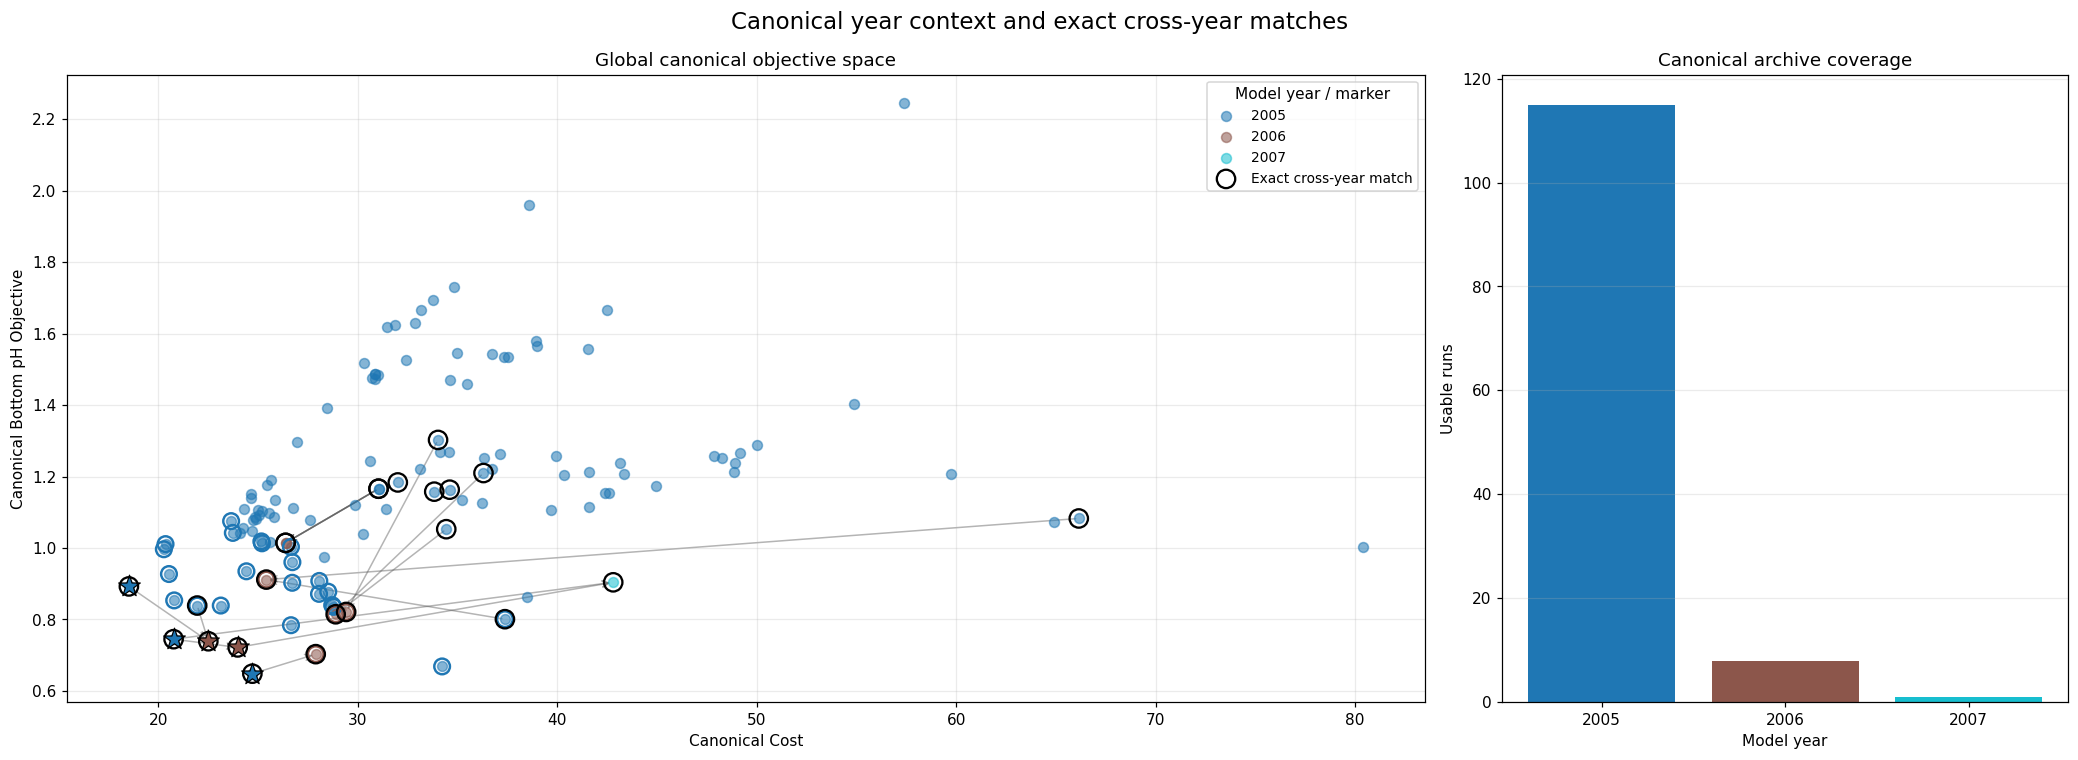

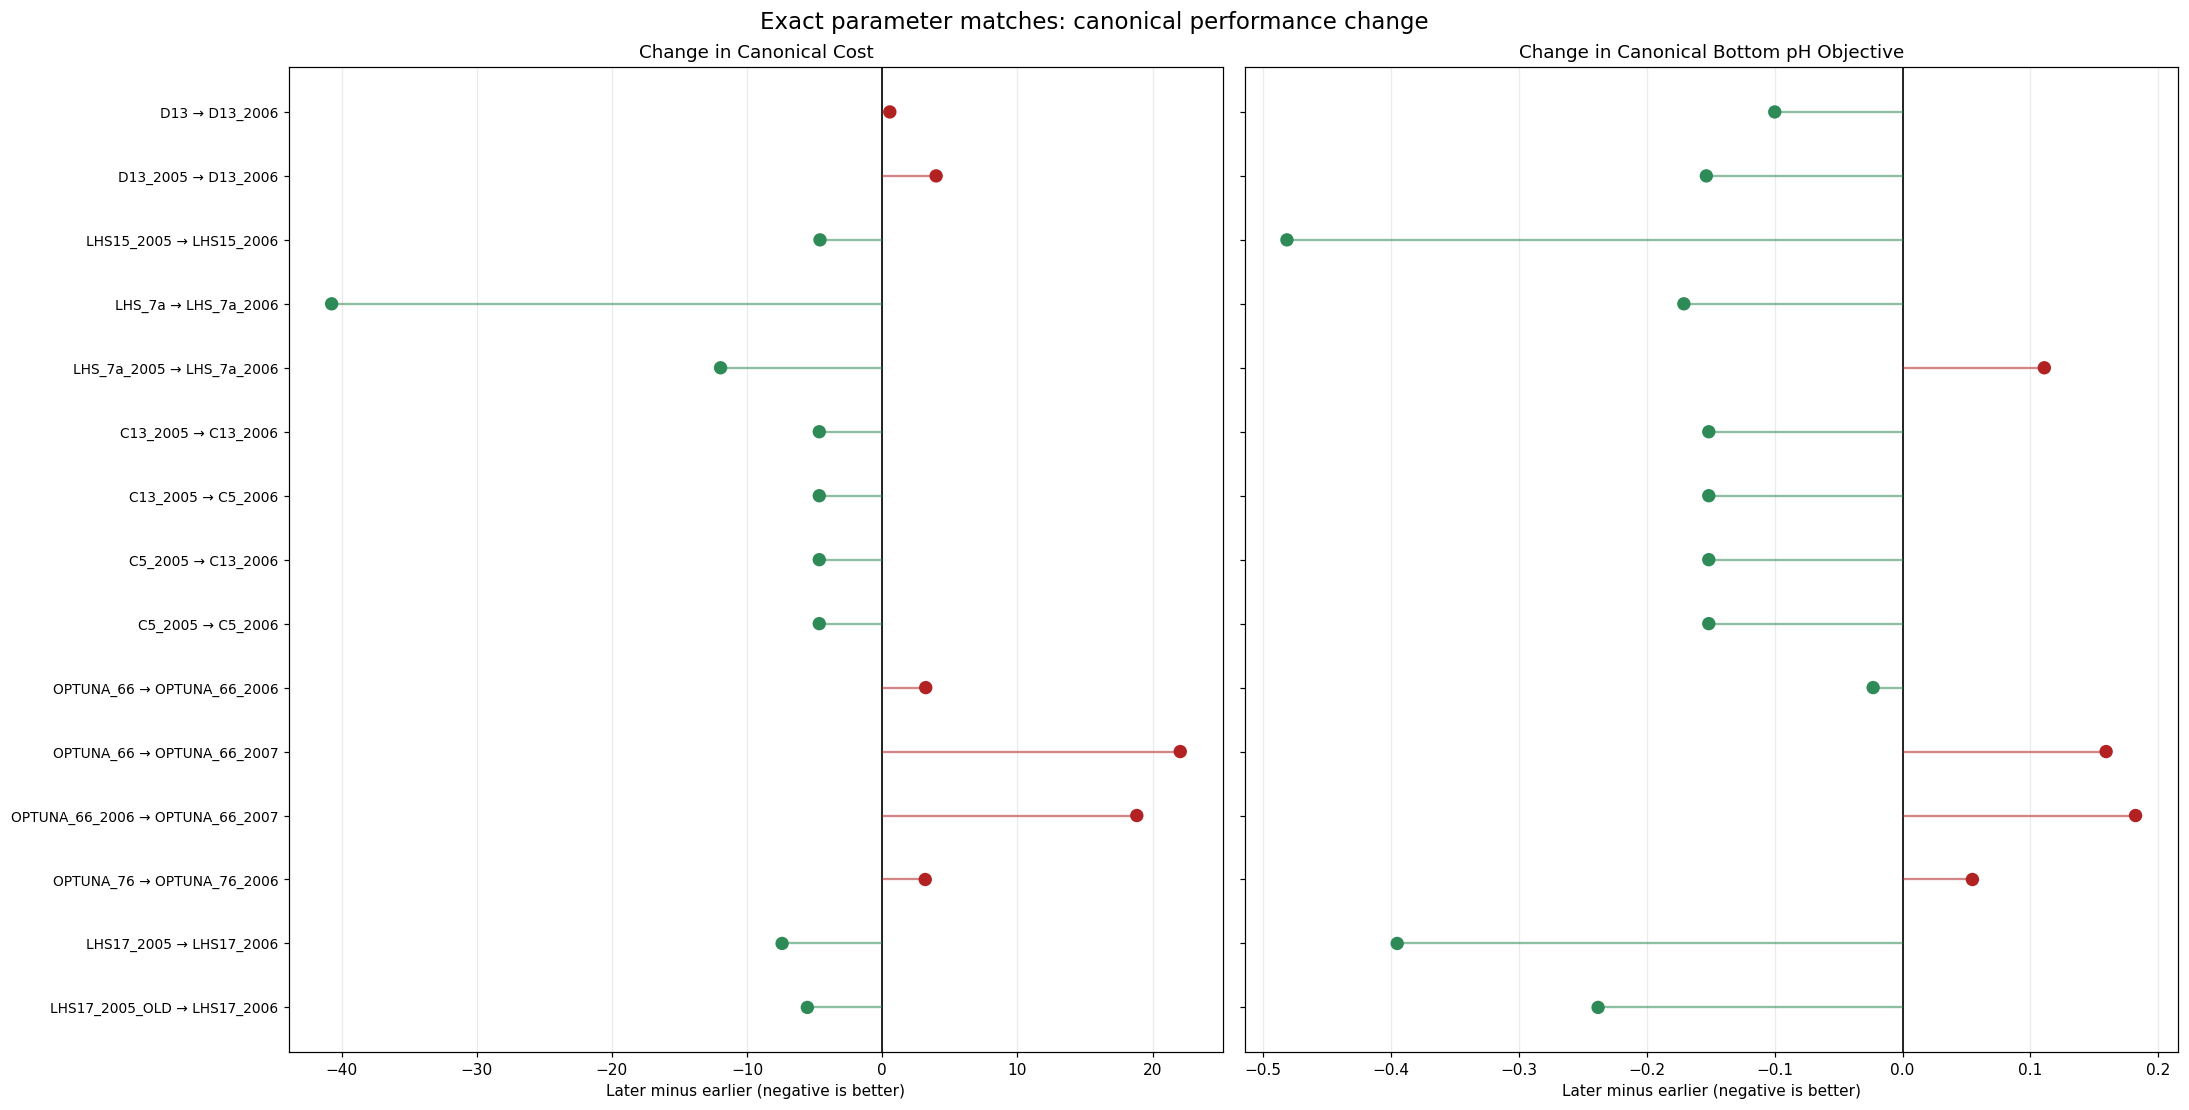

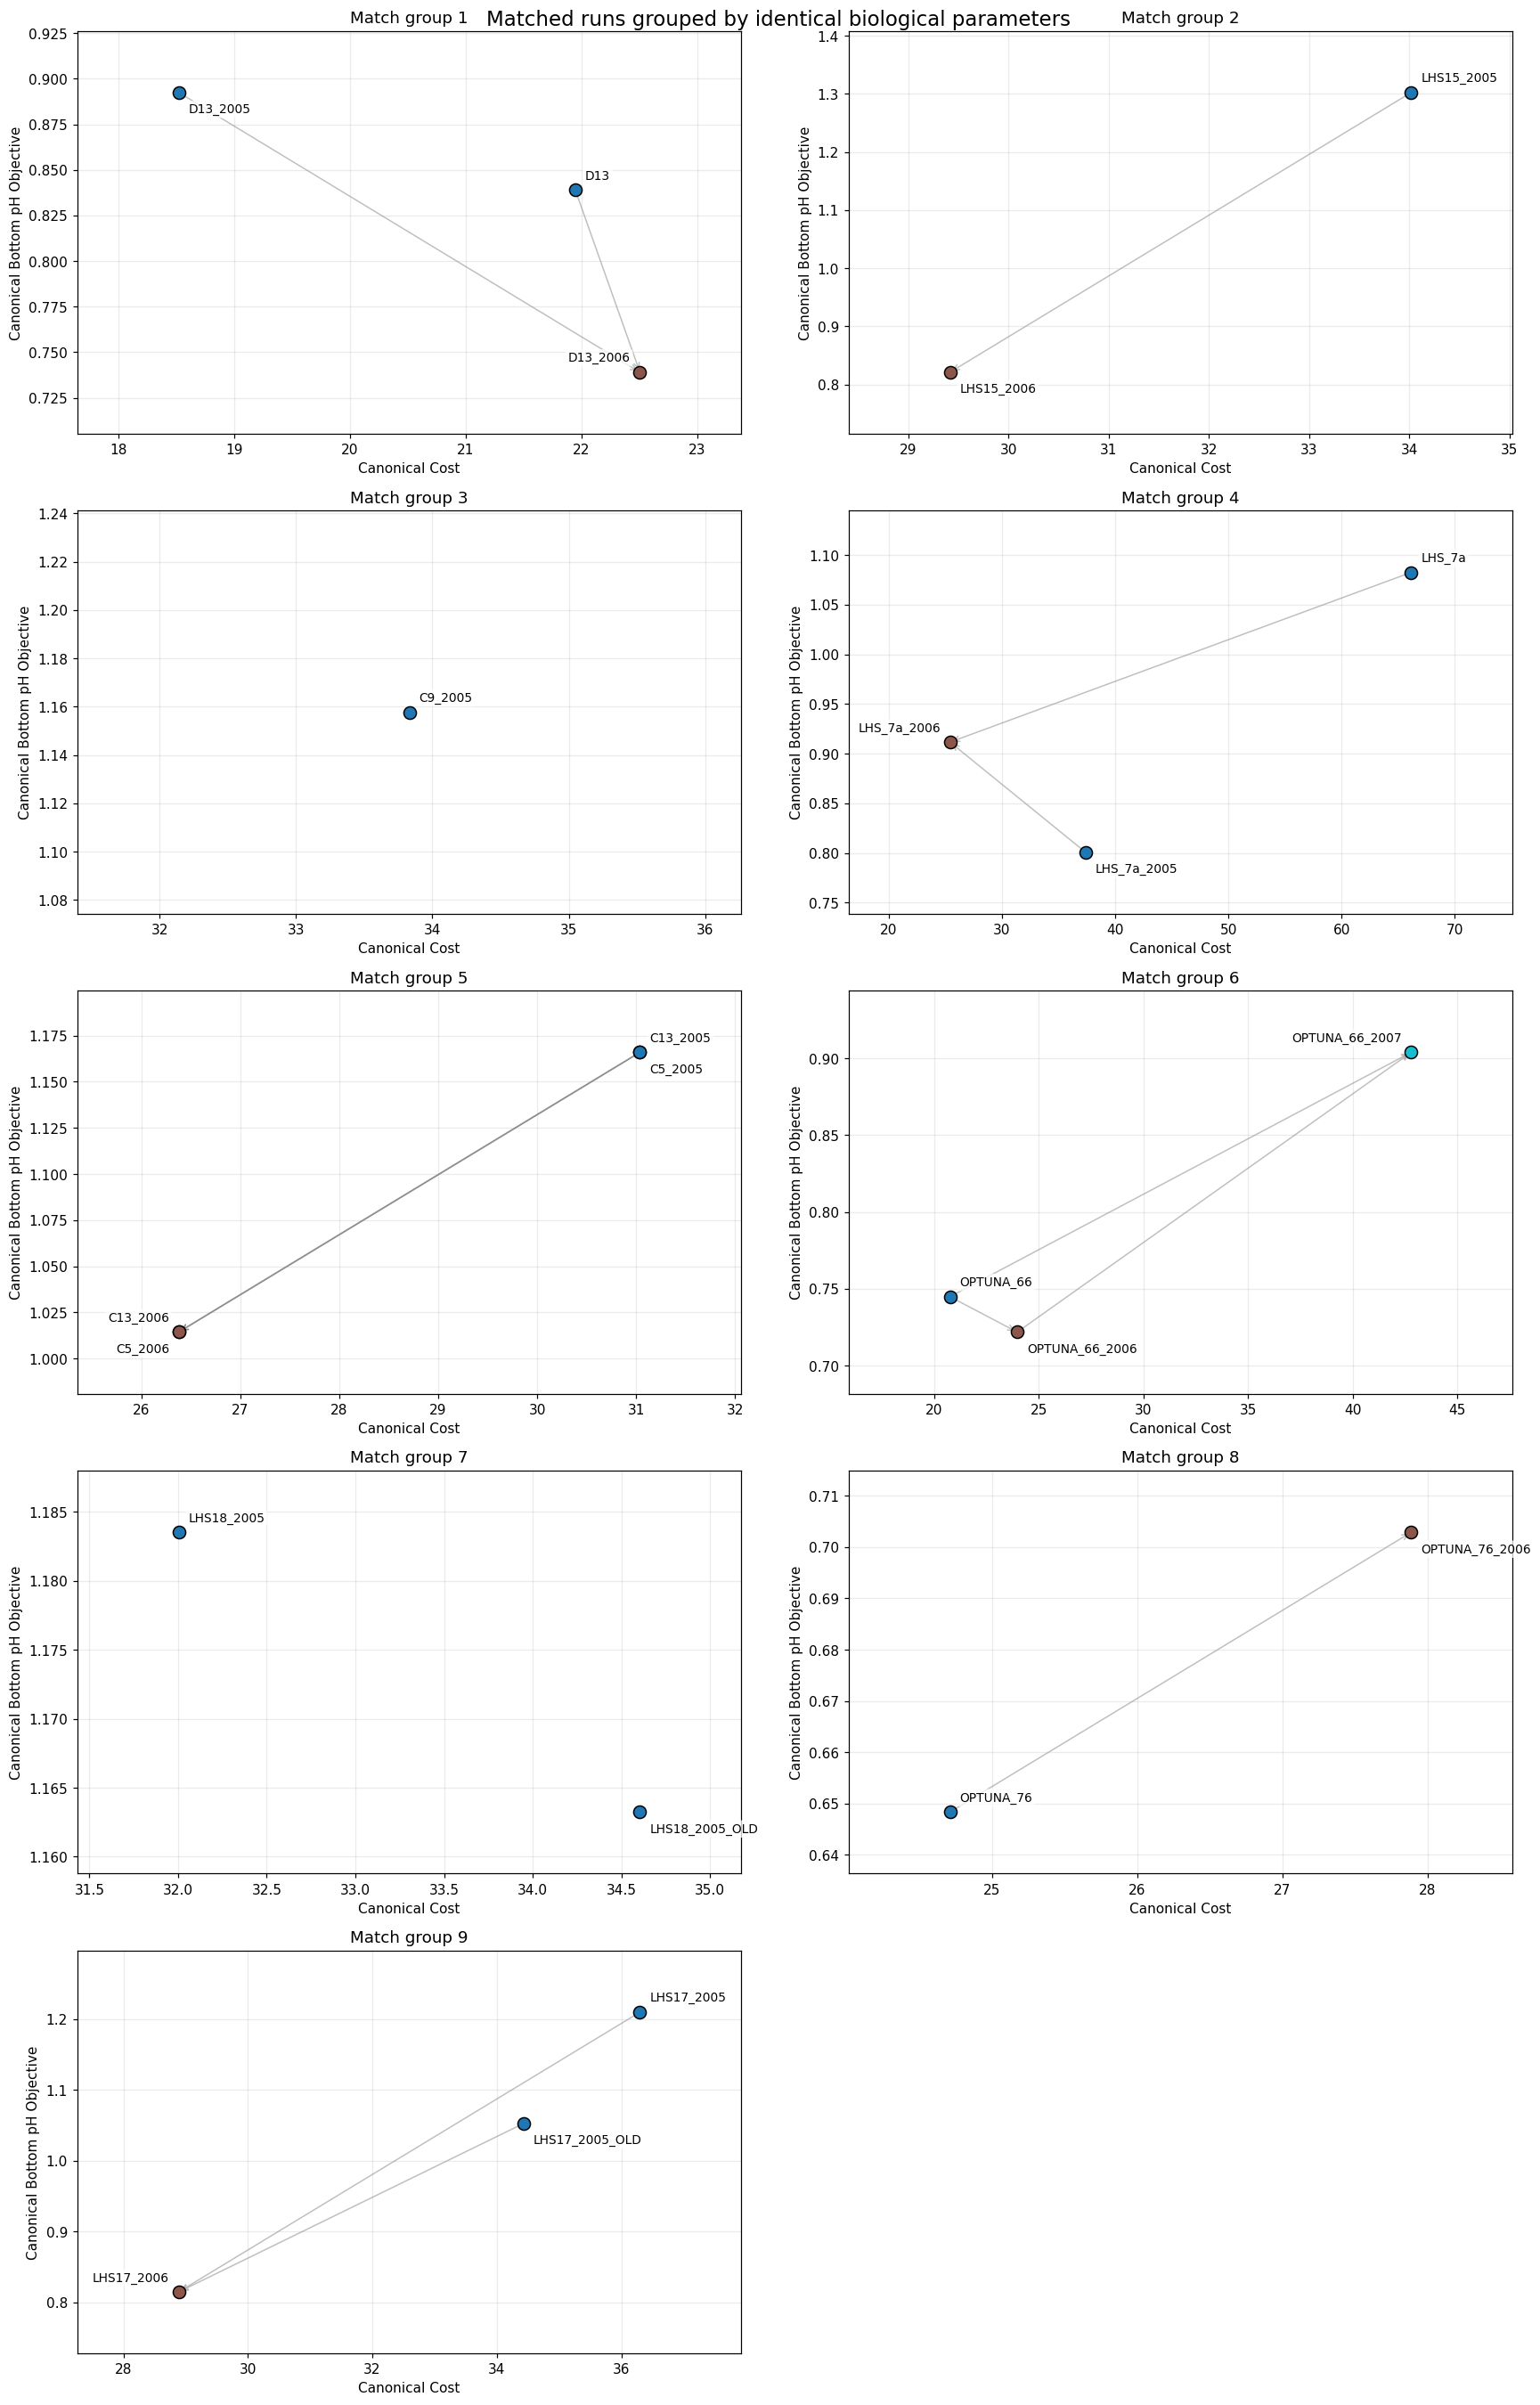

In [6]:
DF_model_year_summary = cpu.model_year_summary(
    DF_analysis, objective_columns=objective_columns
)
DF_matched_year_comparisons = cpu.matched_year_comparisons(
    DF_analysis, objective_columns=objective_columns
)
display(DF_model_year_summary)

if not DF_matched_year_comparisons.empty:
    display(DF_matched_year_comparisons.head(30))

cplot.plot_model_year_context(
    DF_analysis, DF_model_year_summary, DF_matched_year_comparisons, objective_columns,
    maximum_rank=NEAR_PARETO_RANK,
    output_directory=OUTPUT_PATHS.figure_directory if SAVE_AUDIT_OUTPUTS else None,
)

## 5. Future-policy context without historical exclusion

,Policy,Compliant,Runs,Median Canonical Cost,Median Canonical Bottom pH Objective,Near-Pareto Runs
0,Physical Advection Policy Compliant,False,66,28.383740,1.105712,15
1,Physical Advection Policy Compliant,True,58,33.883283,1.197310,16
2,Biological Advection Policy Compliant,False,66,27.258168,1.085757,19
3,Biological Advection Policy Compliant,True,58,34.594728,1.207729,12
4,All Tracer Advection Policy Compliant,False,73,28.289962,1.104254,19
5,All Tracer Advection Policy Compliant,True,51,34.432229,1.206993,12
6,CPP Policy Valid,True,124,30.942430,1.134379,31


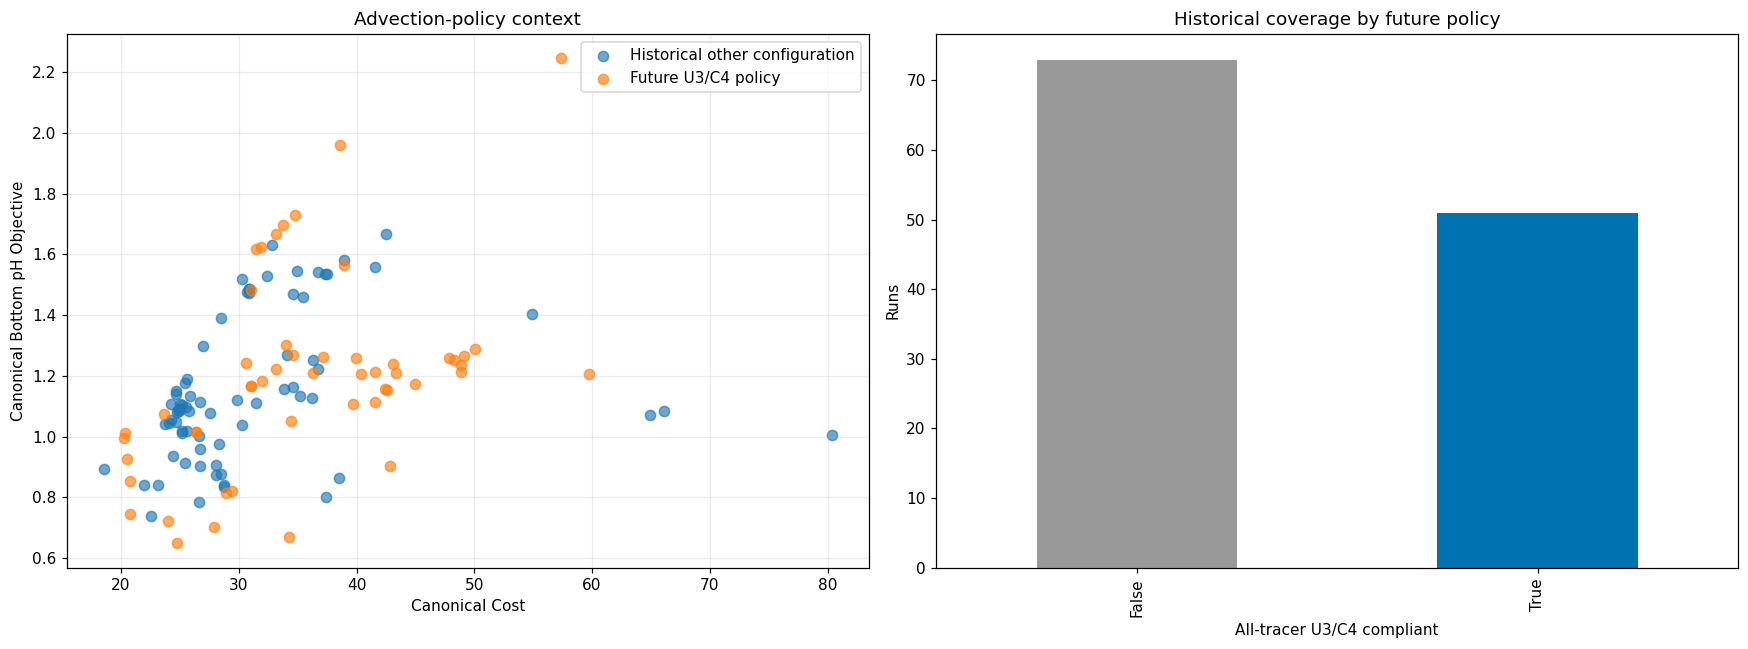

In [7]:
policy_columns = [
    "Physical Advection Policy Compliant",
    "Biological Advection Policy Compliant",
    "All Tracer Advection Policy Compliant",
    "CPP Policy Valid",
]
policy_rows = []
for policy in policy_columns:
    if policy not in DF_analysis:
        continue
    for level, group in DF_analysis.groupby(policy, dropna=False):
        policy_rows.append({
            "Policy": policy, "Compliant": level, "Runs": len(group),
            f"Median {objective_columns[0]}": group[objective_columns[0]].median(),
            f"Median {objective_columns[1]}": group[objective_columns[1]].median(),
            "Near-Pareto Runs": int(group["Near Pareto"].sum()),
        })
DF_policy_summary = pd.DataFrame(policy_rows)
display(DF_policy_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
policy = "All Tracer Advection Policy Compliant"
for compliant, group in DF_analysis.groupby(policy, dropna=False):
    label = "Future U3/C4 policy" if compliant is True or compliant == True else "Historical other configuration"
    axes[0].scatter(group[objective_columns[0]], group[objective_columns[1]], alpha=0.65, s=45, label=label)
axes[0].set(xlabel=objective_columns[0], ylabel=objective_columns[1], title="Advection-policy context")
axes[0].legend()
axes[0].grid(alpha=0.25)
DF_policy_summary.loc[DF_policy_summary["Policy"].eq(policy)].plot.bar(
    x="Compliant", y="Runs", ax=axes[1], legend=False, color=["0.6", "#0072B2"]
)
axes[1].set(title="Historical coverage by future policy", ylabel="Runs", xlabel="All-tracer U3/C4 compliant")
fig.tight_layout()
if SAVE_AUDIT_OUTPUTS:
    cpu.save_figure(fig, OUTPUT_PATHS.figure_directory / "canonical_advection_policy_context.png")
plt.show()

## 6. Numeric, categorical, and confounding diagnostics

In [8]:
prior_context = pd.read_csv(PARAMETER_PRIORS_FILE)
numeric_parameters = [
    row.parameter for row in DF_priors.itertuples(index=False)
    if row.parameter_type in {"float", "integer"}
    and row.parameter in DF_analysis
    and pd.to_numeric(DF_analysis[row.parameter], errors="coerce").nunique() > 1
]
categorical_parameters = [
    row.parameter for row in DF_priors.itertuples(index=False)
    if row.parameter_type in {"categorical", "boolean"}
    and row.parameter in DF_analysis
]
for cpp_option in ["CACO3", "RIVER_SEDIMENT", "USE_MOCSY"]:
    if cpp_option in DF_analysis and cpp_option not in categorical_parameters:
        categorical_parameters.append(cpp_option)

DF_numeric_screening = cpu.numeric_screening_summary(
    DF_analysis, numeric_parameters, objective_columns
)
DF_categorical_screening = cpu.categorical_screening_summary(
    DF_analysis, categorical_parameters
)
DF_confounding = cpu.parameter_confounding(
    DF_analysis, numeric_parameters, threshold=STRONG_CONFOUNDING_THRESHOLD
)
association_columns = [column for column in DF_numeric_screening if column.startswith("Spearman:")]
if association_columns:
    DF_numeric_screening["Strongest Absolute Association"] = (
        DF_numeric_screening[association_columns].abs().max(axis=1)
    )
    DF_numeric_screening = DF_numeric_screening.sort_values(
        "Strongest Absolute Association", ascending=False
    )
display(DF_numeric_screening.head(30))
display(DF_categorical_screening)
display(DF_confounding.head(30))

,Parameter,Available,Coverage,Unique Values,Tested Low,Tested High,Promising Count,Promising 10%,Promising Median,Promising 90%,Spearman: Canonical Cost,Spearman: Canonical Bottom pH Objective,Strongest Absolute Association
21,bgamma6,124,1.0,20,0.005000,0.100000,31,0.010000,0.060918,0.100000,-0.635029,-0.516414,0.635029
0,reg1,124,1.0,19,0.100000,0.400000,31,0.106454,0.200000,0.200000,-0.583372,-0.447378,0.583372
6,rrg1,124,1.0,7,0.100000,0.300000,31,0.100000,0.200000,0.300000,-0.565523,-0.463594,0.565523
28,bUmax_nspc1,124,1.0,40,0.002740,0.027400,31,0.002740,0.002740,0.007773,0.565007,0.045460,0.565007
7,rrg2,124,1.0,7,0.100000,0.300000,31,0.100000,0.200000,0.300000,-0.563929,-0.464257,0.563929
8,beta1,124,1.0,22,0.307665,2.250000,31,0.703302,1.500000,2.250000,-0.563117,-0.557845,0.563117
13,amaxs2,124,1.0,8,0.100000,0.200000,31,0.100000,0.130000,0.190000,-0.556475,-0.306404,0.556475
9,beta2,124,1.0,22,0.150000,2.000000,31,0.432543,0.500000,1.750000,-0.549122,-0.501668,0.549122
11,akz2,124,1.0,16,0.500000,5.000000,31,0.500000,1.000000,2.000000,-0.543879,-0.420870,0.543879
5,rrb2,124,1.0,7,0.200000,0.400000,31,0.200000,0.300000,0.400000,-0.543506,-0.414257,0.543506


,Parameter,Category,Runs,Promising Runs,P(Promising | Category),95% Low,95% High,Enrichment
0,CACO3,False,118,31,0.262712,0.191688,0.348699,1.050847
1,CACO3,True,6,0,0.000000,0.000000,0.390343,0.000000
2,RIVER_SEDIMENT,False,124,31,0.250000,0.182075,0.332949,1.000000
3,USE_MOCSY,False,124,31,0.250000,0.182075,0.332949,1.000000


,Parameter 1,Parameter 2,Spearman Correlation,Absolute Correlation
0,rrb1,rrb2,0.999992,0.999992
1,gmaxs1,gmaxs2,0.999944,0.999944
2,rrg1,rrg2,0.999897,0.999897
3,rrb1,rrg2,0.989748,0.989748
4,rrb2,rrg2,0.989740,0.989740
5,rrb2,rrg1,0.989725,0.989725
6,rrb1,rrg1,0.989693,0.989693
7,gmaxs1,nl_tnu2_tracer9,0.951829,0.951829
8,gmaxs2,nl_tnu2_tracer9,0.950506,0.950506
9,akz1,akz2,0.934849,0.934849


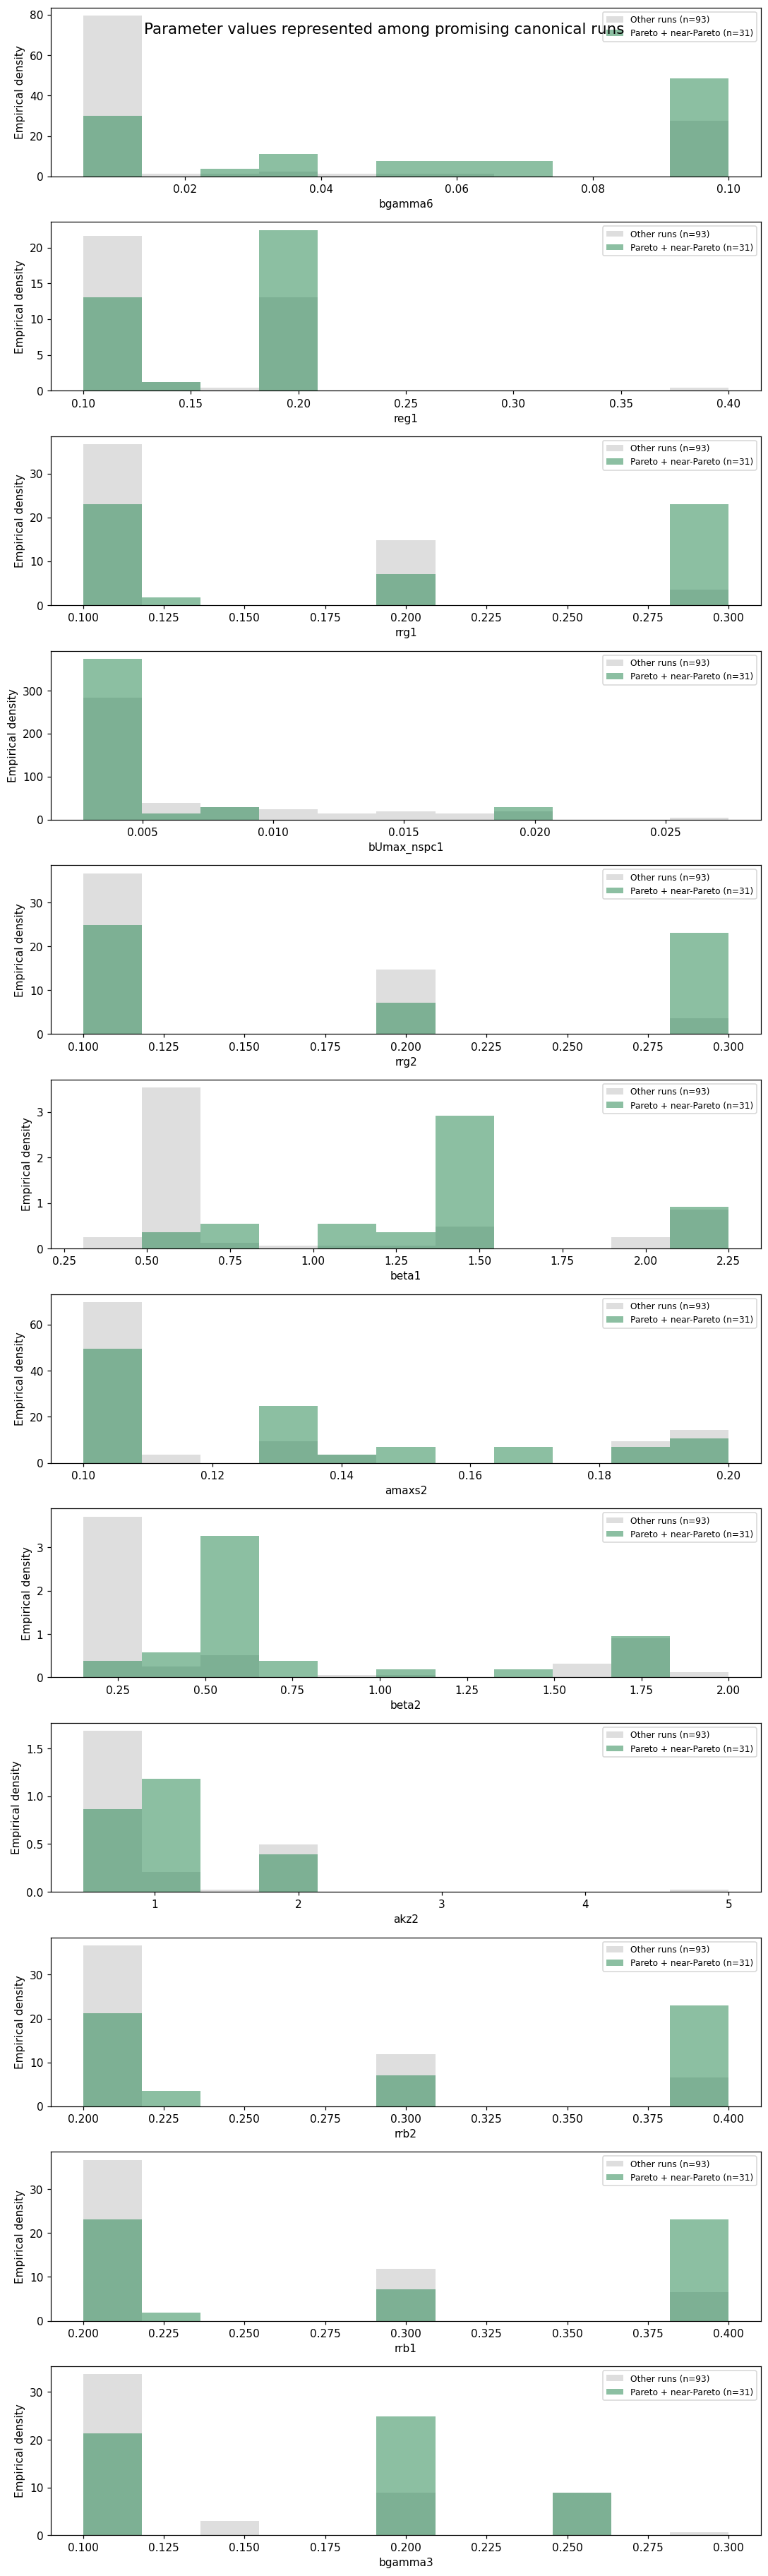

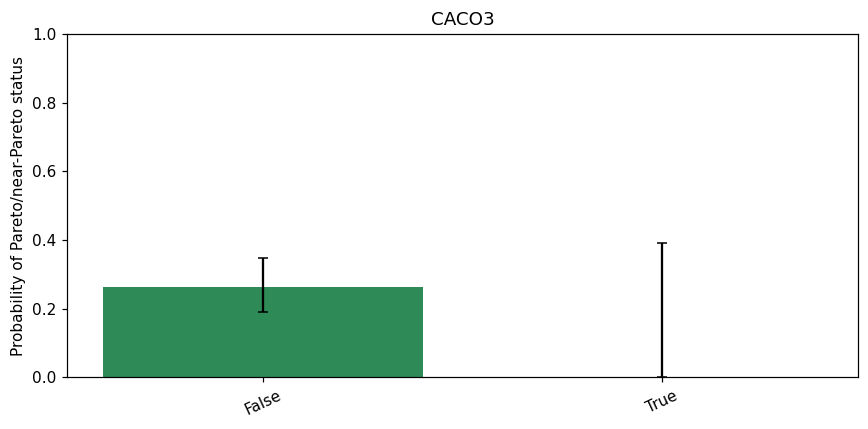

/Users/akbaskind/opt/anaconda3/envs/my_env/lib/python3.12/site-packages/matplotlib/cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


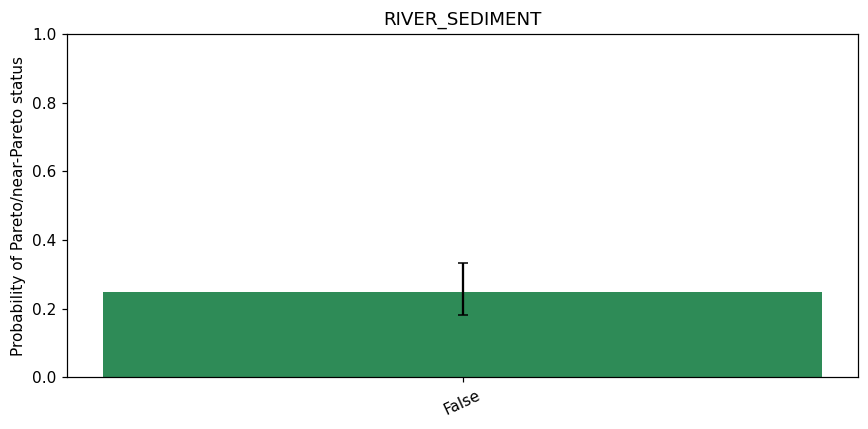

/Users/akbaskind/opt/anaconda3/envs/my_env/lib/python3.12/site-packages/matplotlib/cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


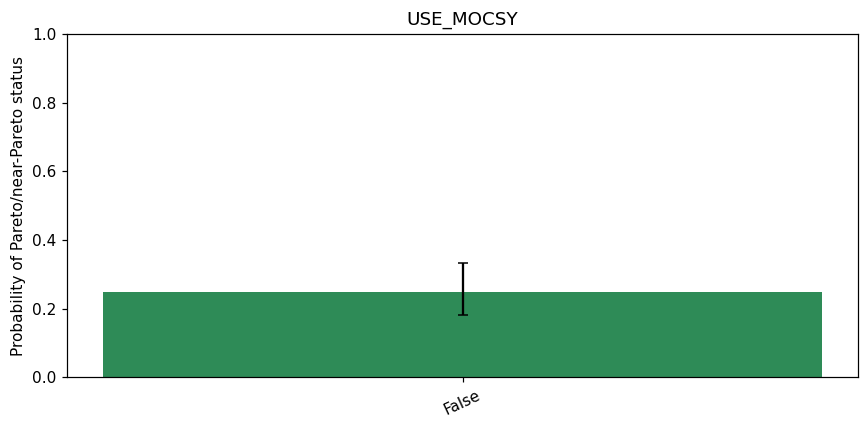

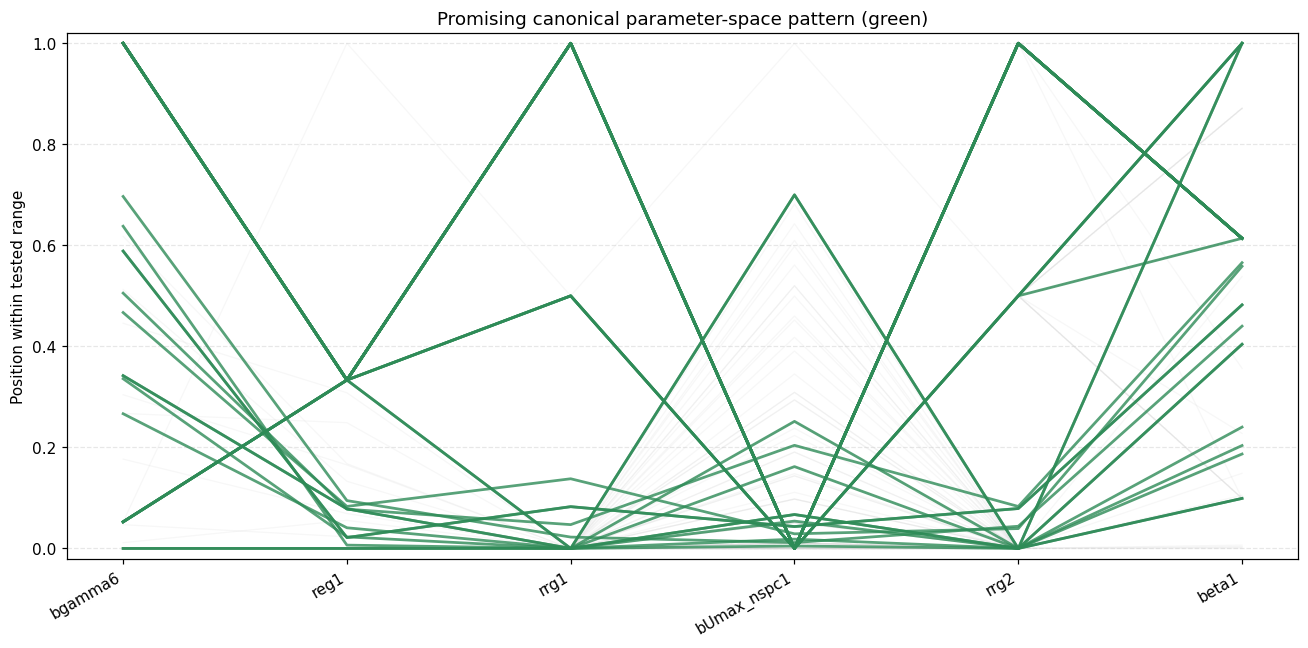

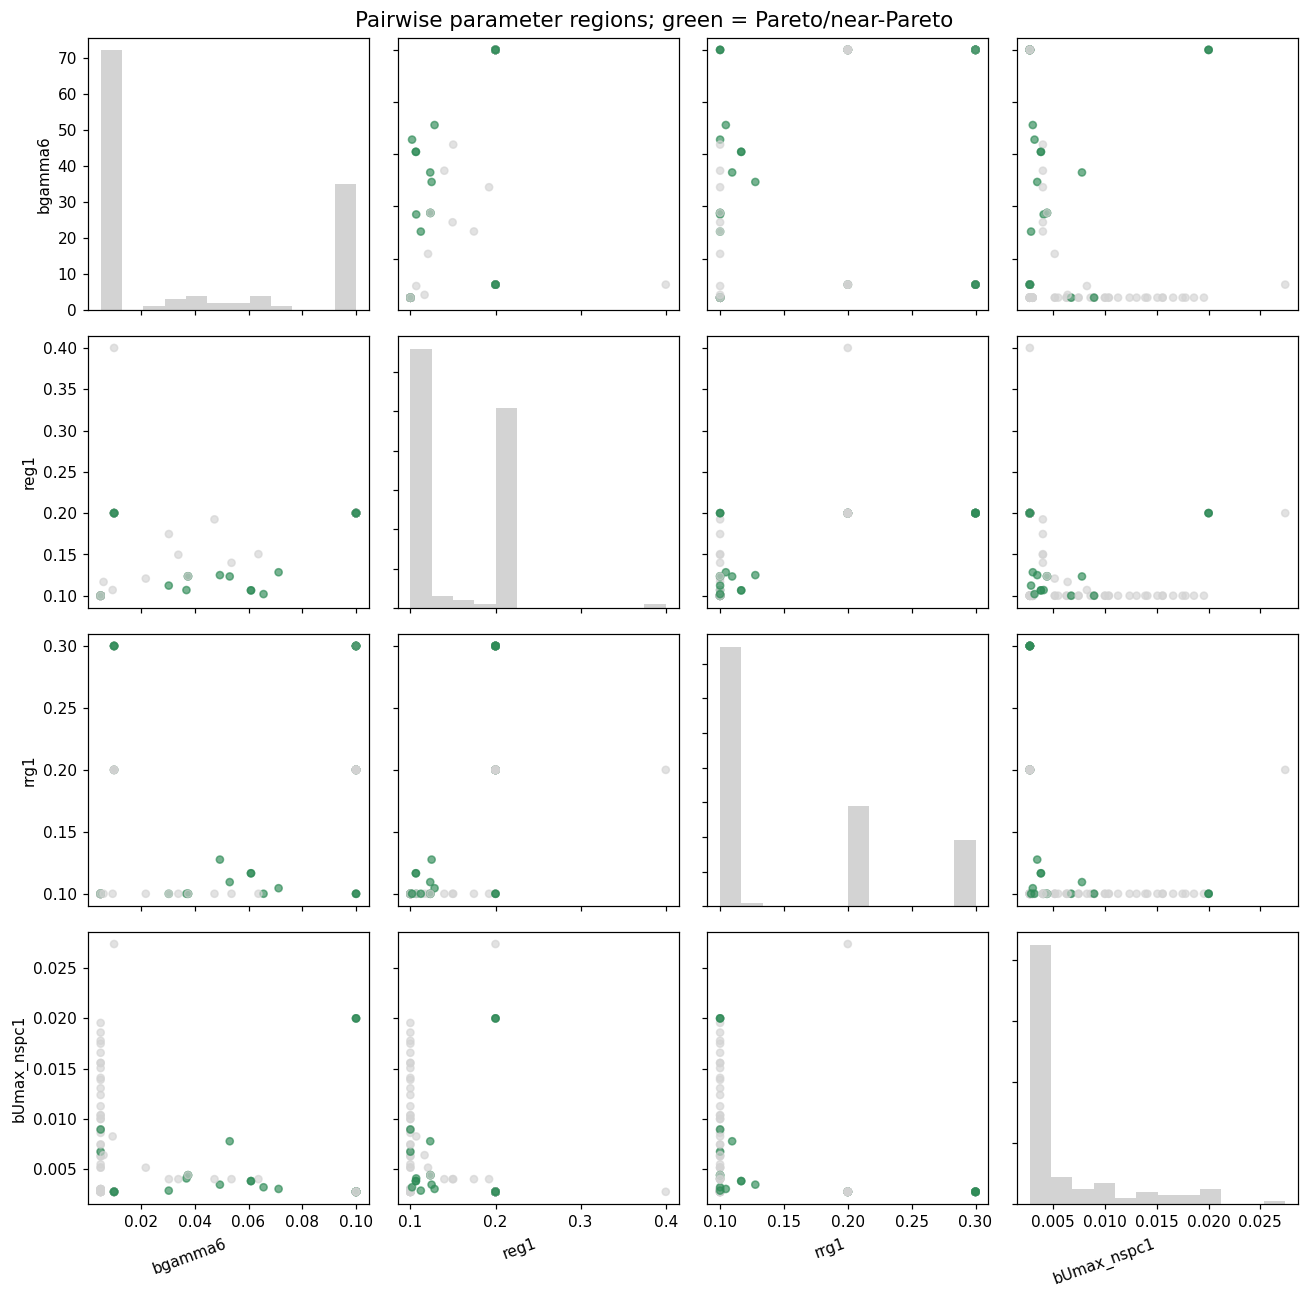

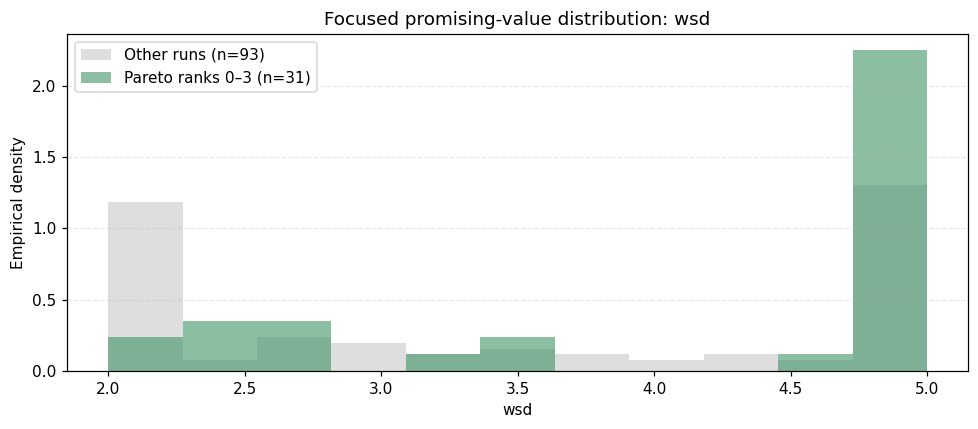

In [9]:
plot_parameters = DF_numeric_screening["Parameter"].head(N_PARAMETER_DISTRIBUTIONS_TO_PLOT).tolist()
cplot.plot_parameter_evidence(
    DF_analysis, plot_parameters, DF_categorical_screening,
    output_directory=OUTPUT_PATHS.figure_directory if SAVE_AUDIT_OUTPUTS else None,
)
cplot.plot_focused_parameter(
    DF_analysis, FOCUSED_PARAMETER_TO_INSPECT, maximum_rank=NEAR_PARETO_RANK,
    output_directory=OUTPUT_PATHS.figure_directory if SAVE_AUDIT_OUTPUTS else None,
)

## 7. Nonlinear screening, readiness, and search budget

,Objective,Model,Runs,Parameters,Held-out R2,Held-out MAE
0,Canonical Cost,Mixed-type Random Forest,124,36,0.515465,3.945231
1,Canonical Cost,Mean baseline,124,0,-0.004271,7.536187
2,Canonical Bottom pH Objective,Mixed-type Random Forest,124,36,0.408233,0.132431
3,Canonical Bottom pH Objective,Mean baseline,124,0,-0.015735,0.210139


,Objective,Parameter,Mean_Importance,SD_Importance,Positive_Fraction,Rank
16,Canonical Bottom pH Objective,beta1,1.018029e-01,3.938766e-02,1.00,1.0
19,Canonical Bottom pH Objective,bgamma4,1.934663e-02,1.625951e-02,0.88,2.0
17,Canonical Bottom pH Objective,beta2,1.079576e-02,6.396545e-03,0.96,3.0
1,Canonical Bottom pH Objective,Chl2cs1_m,5.391974e-03,9.661267e-03,0.72,4.0
22,Canonical Bottom pH Objective,bgamma6,2.992191e-03,4.159015e-03,0.88,5.0
15,Canonical Bottom pH Objective,bdenit,2.605581e-03,5.165159e-03,0.80,6.0
33,Canonical Bottom pH Objective,rrg2,1.927613e-03,1.457249e-03,0.84,7.0
32,Canonical Bottom pH Objective,rrg1,1.778757e-03,1.248933e-03,0.96,8.0
0,Canonical Bottom pH Objective,CACO3,1.614938e-03,2.205888e-03,0.68,9.0
20,Canonical Bottom pH Objective,bgamma5,1.332117e-03,3.576597e-03,0.64,10.0


,Parameter,Decision,Bottom pH relevance,Holistic relevance,Empirical Evidence,Readiness,Confounded,legacy_decision
27,Chl2cs2_m,fixed,unknown,unknown,Strongly confounded,Fix cautiously,True,fixed
13,amaxs2,fixed,unknown,unknown,Strongly confounded,Fix cautiously,True,fixed
18,bgamma3,fixed,unknown,unknown,Strongly confounded,Fix cautiously,True,fixed
2,gmaxs1,reserve,unknown,unknown,Strongly confounded,Held in reserve,True,reserve
3,gmaxs2,reserve,unknown,unknown,Strongly confounded,Held in reserve,True,reserve
4,rrb1,reserve,unknown,unknown,Strongly confounded,Held in reserve,True,reserve
5,rrb2,reserve,unknown,unknown,Strongly confounded,Held in reserve,True,reserve
6,rrg1,reserve,unknown,unknown,Strongly confounded,Held in reserve,True,reserve
7,rrg2,reserve,unknown,unknown,Strongly confounded,Held in reserve,True,reserve
17,aknh4s2,reserve,unknown,unknown,Insufficient archive evidence,Insufficient evidence,False,reserve


,Active numeric parameters,Categorical burden,Effective dimensions (heuristic),Trial budget,Assessment,Interpretation
0,13,0,13,30,Focused,Reasonable for focused optimization; interacti...


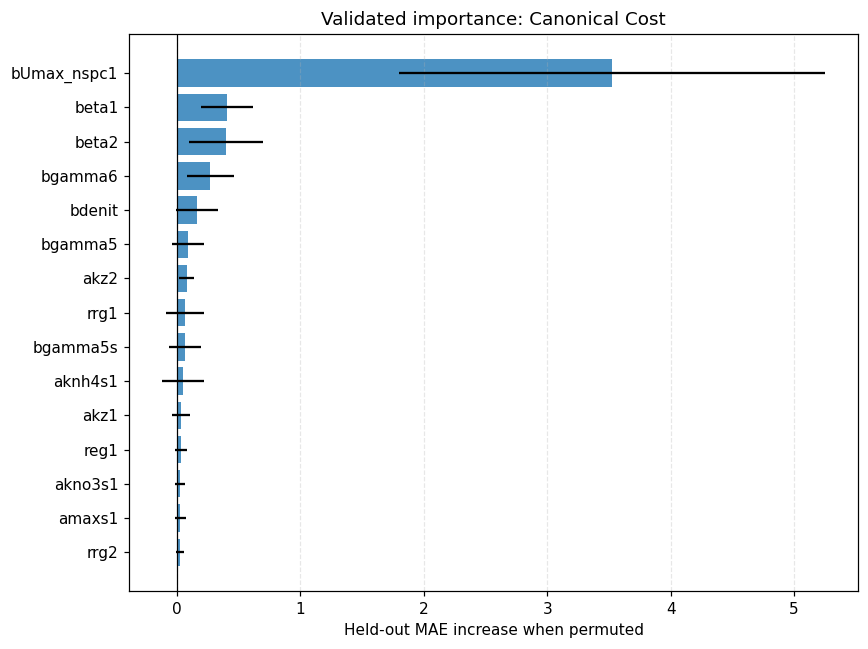

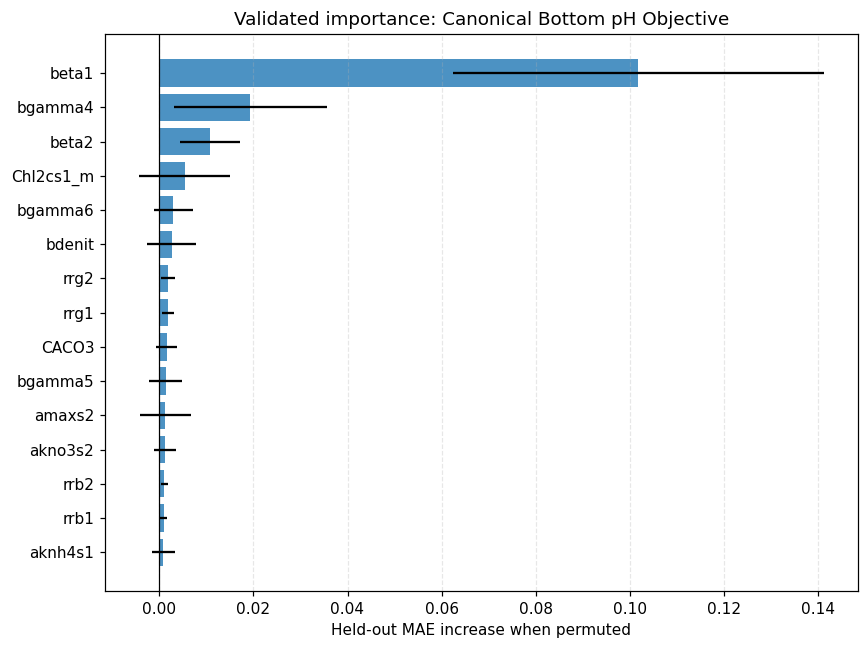

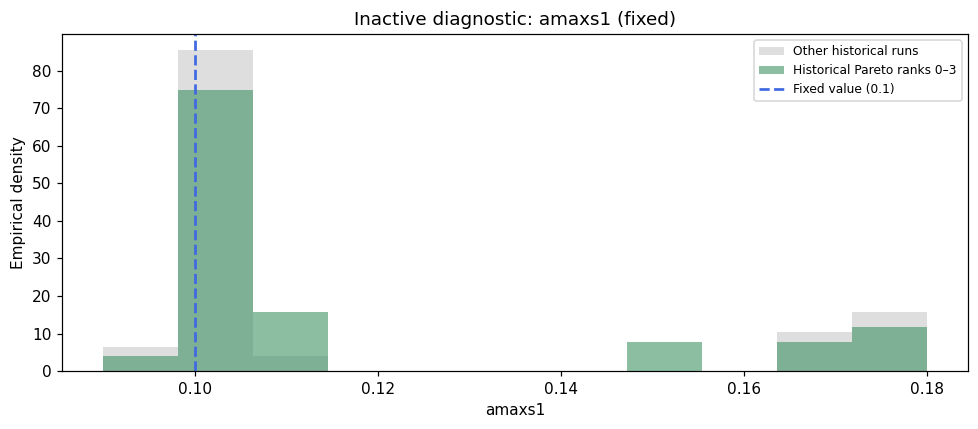

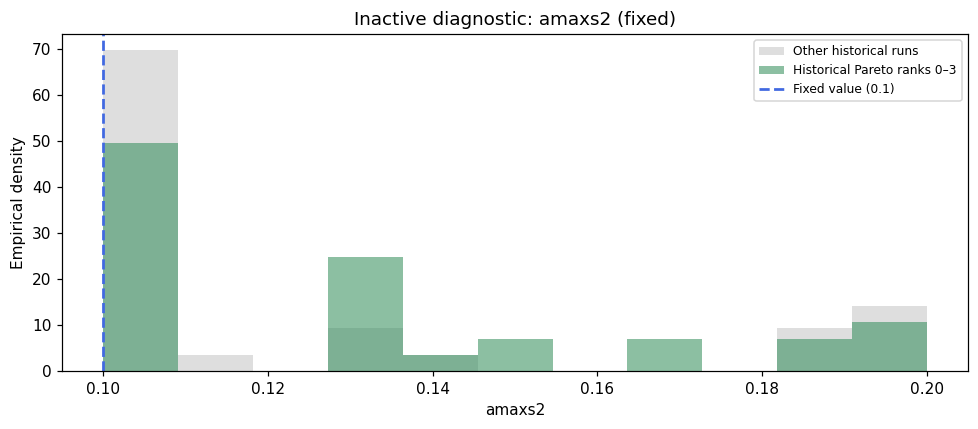

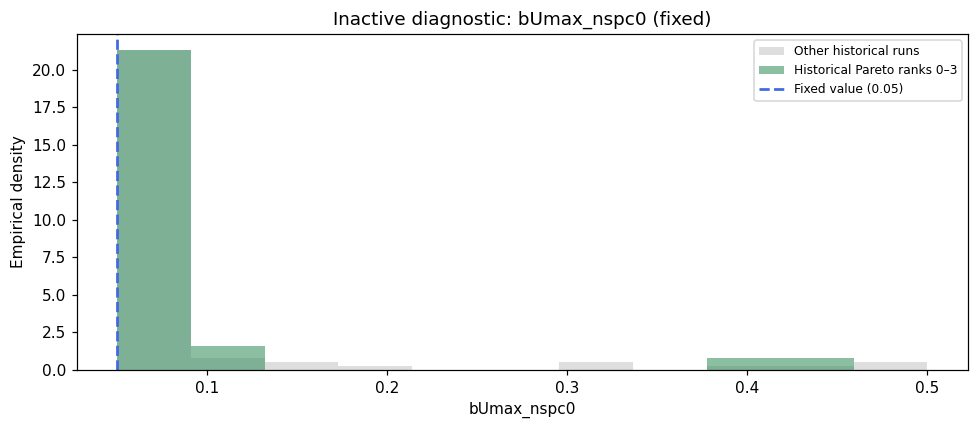

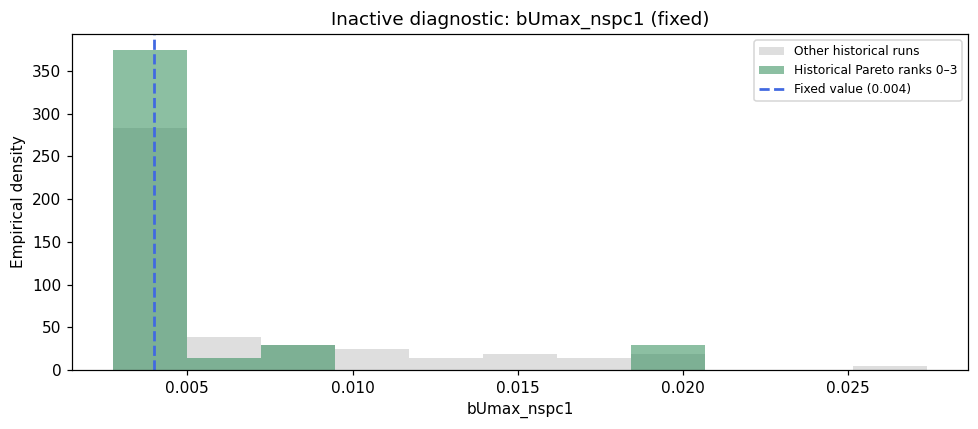

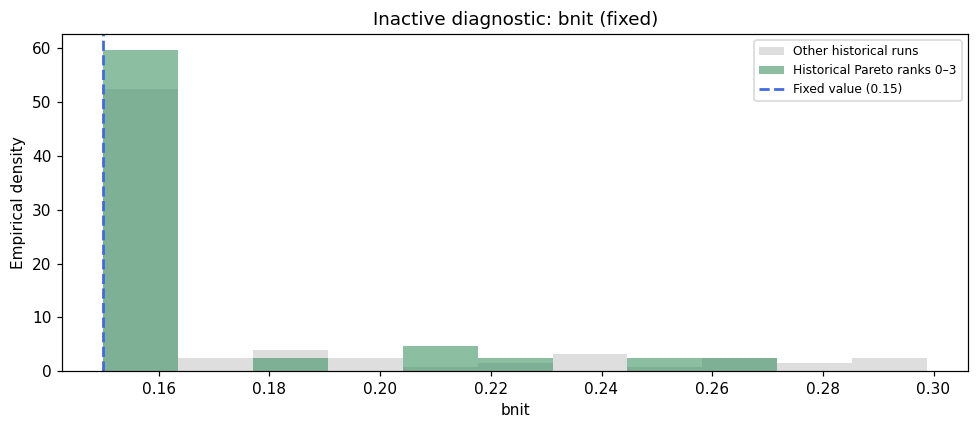

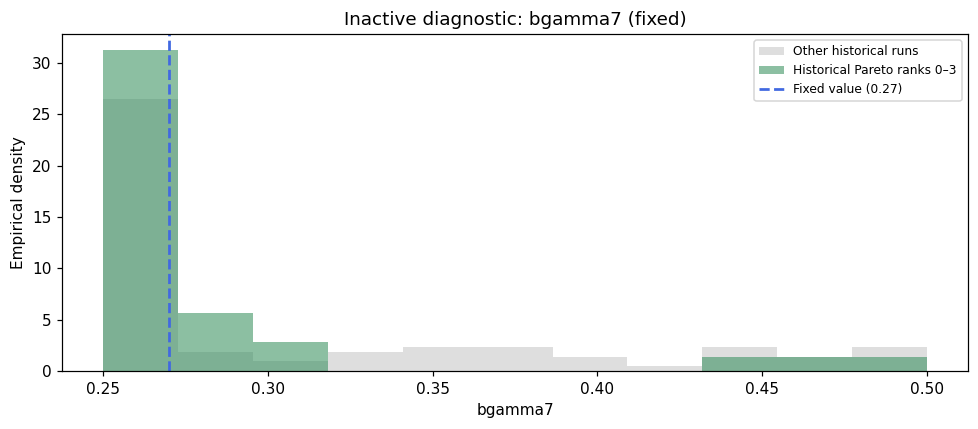

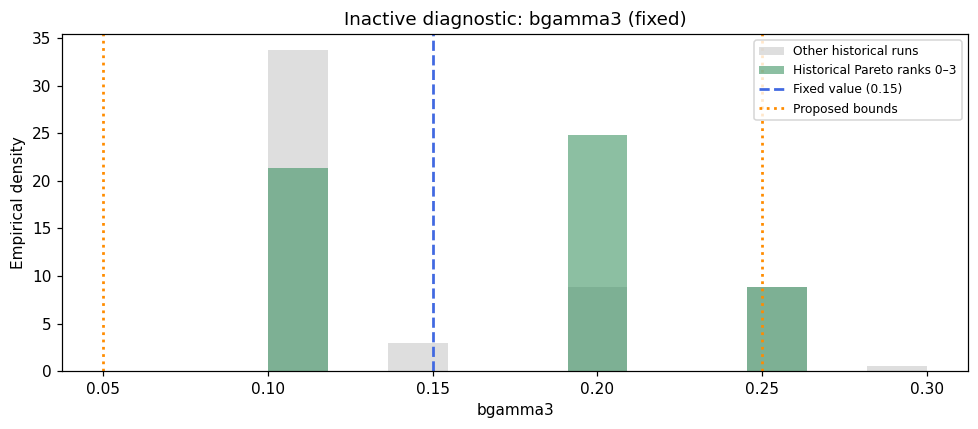

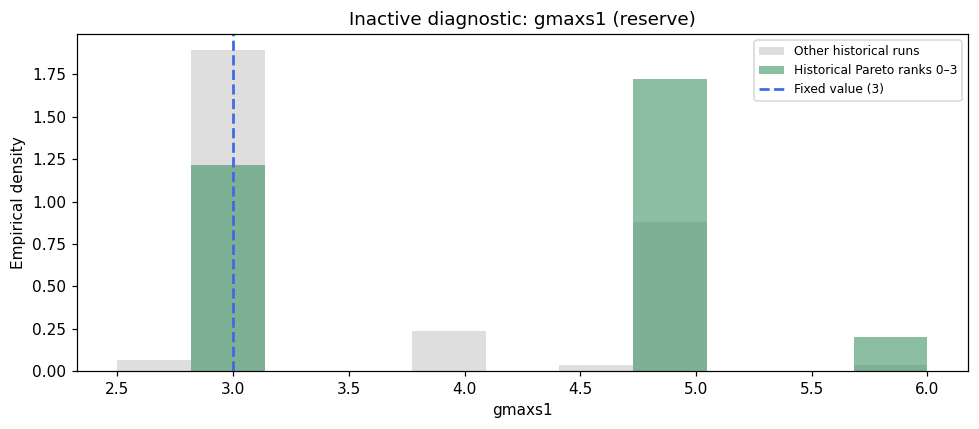

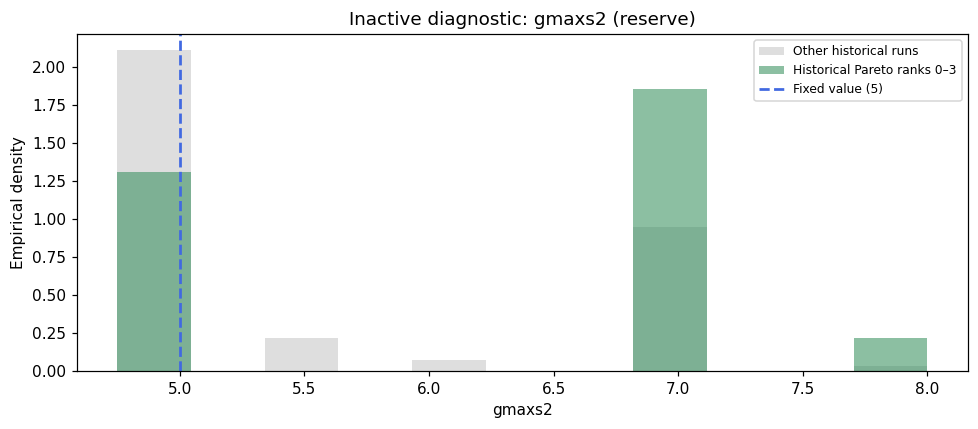

,Parameter,Decision,Current Value,Proposed Low,Proposed High,Usable Runs,Promising Runs,Tested Low,Tested High
0,amaxs1,fixed,0.100,NaN,NaN,124,31,0.09000,0.180000
1,amaxs2,fixed,0.100,NaN,NaN,124,31,0.10000,0.200000
2,bUmax_nspc0,fixed,0.050,NaN,NaN,124,31,0.05000,0.500000
3,bUmax_nspc1,fixed,0.004,NaN,NaN,124,31,0.00274,0.027400
4,bnit,fixed,0.150,NaN,NaN,124,31,0.15000,0.298785
5,bgamma7,fixed,0.270,NaN,NaN,124,31,0.25000,0.500000
6,bgamma3,fixed,0.150,0.05,0.25,124,31,0.10000,0.300000
7,gmaxs1,reserve,3.000,NaN,NaN,124,31,2.50000,6.000000
8,gmaxs2,reserve,5.000,NaN,NaN,124,31,4.75000,8.000000


Canonical diagnostic tables: /Users/akbaskind/Desktop/Optimization/MO-BIO-CANONICAL/audit


In [10]:
DF_model_performance = pd.DataFrame()
DF_nonlinear_importance = pd.DataFrame()
if RUN_NONLINEAR_SCREENING and (numeric_parameters or categorical_parameters):
    try:
        DF_model_performance, DF_nonlinear_importance = cpu.cross_validated_mixed_importance(
            DF_analysis, numeric_parameters, categorical_parameters,
            objective_columns, random_state=RANDOM_SEED,
        )
        display(DF_model_performance)
        display(DF_nonlinear_importance.sort_values(["Objective", "Rank"]).head(40))
    except (ImportError, ValueError) as error:
        print(f"Nonlinear screening unavailable: {error}")

DF_readiness = cpu.readiness_summary(
    DF_priors, DF_numeric_screening, DF_categorical_screening, DF_confounding
)
DF_readiness = DF_readiness.merge(
    prior_context[["parameter", "legacy_decision"]].rename(columns={"parameter": "Parameter"}),
    on="Parameter", how="left",
)
display(DF_readiness.sort_values(["Readiness", "Parameter"]))

active_numeric = DF_priors.loc[
    DF_priors["decision"].eq("active") & DF_priors["parameter_type"].isin(["float", "integer"])
]
active_categorical = DF_priors.loc[
    DF_priors["decision"].eq("active") & DF_priors["parameter_type"].isin(["categorical", "boolean"])
]
category_counts = [len(cpu.parse_prior_choices(row)) for _, row in active_categorical.iterrows()]
budget = cpu.budget_assessment(len(active_numeric), category_counts, TRIAL_BUDGET)
display(pd.DataFrame([budget]))

cplot.plot_nonlinear_importance(
    DF_model_performance, DF_nonlinear_importance, objective_columns,
    output_directory=OUTPUT_PATHS.figure_directory if SAVE_AUDIT_OUTPUTS else None,
)
DF_inactive_diagnostics = cplot.inactive_parameter_diagnostics(
    DF_analysis, DF_priors, INACTIVE_PARAMETERS_TO_DIAGNOSE,
    maximum_rank=NEAR_PARETO_RANK,
    output_directory=OUTPUT_PATHS.figure_directory if SAVE_AUDIT_OUTPUTS else None,
)
if not DF_inactive_diagnostics.empty:
    display(DF_inactive_diagnostics)

if SAVE_AUDIT_OUTPUTS:
    audit_tables = {
        "canonical_analysis_archive.csv": DF_analysis,
        "canonical_representative_runs.csv": DF_representatives,
        "canonical_model_year_summary.csv": DF_model_year_summary,
        "canonical_matched_year_comparisons.csv": DF_matched_year_comparisons,
        "canonical_policy_summary.csv": DF_policy_summary,
        "canonical_numeric_screening.csv": DF_numeric_screening,
        "canonical_categorical_screening.csv": DF_categorical_screening,
        "canonical_numeric_confounding.csv": DF_confounding,
        "canonical_nonlinear_model_performance.csv": DF_model_performance,
        "canonical_nonlinear_importance.csv": DF_nonlinear_importance,
        "canonical_parameter_readiness.csv": DF_readiness,
    }
    for filename, table in audit_tables.items():
        cpu.atomic_write_csv(table, OUTPUT_PATHS.audit_directory / filename, index=False)
    print(f"Canonical diagnostic tables: {OUTPUT_PATHS.audit_directory}")

## 8. Coverage, observation context, stations, and linked-year diagnostics

Required-component coverage remains strict. CHRP nutrients remain diagnostic-only. The year-context panels distinguish changes in observational support from changes in model performance. Station plots report pH and oxygen RMSE and bias for every station and depth, with Upper Bay stations PD, BR, and CP highlighted in red. An empty `STATION_DIAGNOSTIC_RUNS` control uses the representative runs; list run names explicitly to inspect others. Linked trajectories show how identical biological parameter configurations behave across years.

Required components failing 100% model coverage


,Run Name,component,status,observation_count,paired_count,model_coverage
144,2005_CTRL,surface_ph,incomplete_model_coverage,1821,1815,0.996705
145,2005_CTRL,bottom_ph,incomplete_model_coverage,1302,1299,0.997696
146,2005_CTRL,surface_oxygen,incomplete_model_coverage,1821,1815,0.996705
147,2005_CTRL,bottom_oxygen,incomplete_model_coverage,1302,1299,0.997696
148,2005_CTRL,surface_no3,incomplete_model_coverage,49,48,0.979592
149,2005_CTRL,bottom_no3,incomplete_model_coverage,49,48,0.979592
150,2005_CTRL,surface_nh4,incomplete_model_coverage,49,48,0.979592
151,2005_CTRL,bottom_nh4,incomplete_model_coverage,49,48,0.979592
152,2005_CTRL,surface_si,incomplete_model_coverage,48,47,0.979167
153,2005_CTRL,bottom_si,incomplete_model_coverage,42,41,0.976190


CHRP diagnostic rows: 780 (never included in an objective)
Linked-year annual comparisons: 15
Linked-year pooled component rows: 162


,Parameter Match Group,Earlier Run,Earlier Year,Later Run,Later Year,Earlier Canonical Cost,Later Canonical Cost,Change in Canonical Cost,Earlier Canonical Bottom pH Objective,Later Canonical Bottom pH Objective,Change in Canonical Bottom pH Objective,Earlier Global Pareto Rank,Later Global Pareto Rank,Change in Global Pareto Rank,Direction
0,1da3729dfe57,D13,2005,D13_2006,2006,21.946047,22.504084,0.558037,0.838987,0.739013,-0.099974,1,0,-1,mixed/tradeoff
1,1da3729dfe57,D13_2005,2005,D13_2006,2006,18.521351,22.504084,3.982733,0.892500,0.739013,-0.153488,0,0,0,mixed/tradeoff
2,3d1516e326a5,LHS15_2005,2005,LHS15_2006,2006,34.021126,29.413923,-4.607203,1.302506,0.821029,-0.481477,15,3,-12,better in both
3,5364e5cc5b5e,LHS_7a,2005,LHS_7a_2006,2006,66.144134,25.410641,-40.733493,1.082671,0.911609,-0.171062,8,2,-6,better in both
4,5364e5cc5b5e,LHS_7a_2005,2005,LHS_7a_2006,2006,37.373504,25.410641,-11.962863,0.800773,0.911609,0.110837,2,2,0,mixed/tradeoff
5,797e4cf1dafb,C13_2005,2005,C13_2006,2006,31.037574,26.377008,-4.660565,1.165948,1.014386,-0.151561,12,4,-8,better in both
6,797e4cf1dafb,C13_2005,2005,C5_2006,2006,31.037574,26.377008,-4.660565,1.165948,1.014386,-0.151561,12,4,-8,better in both
7,797e4cf1dafb,C5_2005,2005,C13_2006,2006,31.037574,26.377008,-4.660565,1.165948,1.014386,-0.151561,12,4,-8,better in both
8,797e4cf1dafb,C5_2005,2005,C5_2006,2006,31.037574,26.377008,-4.660565,1.165948,1.014386,-0.151561,12,4,-8,better in both
9,8a834500247f,OPTUNA_66,2005,OPTUNA_66_2006,2006,20.762798,23.975993,3.213196,0.744813,0.721782,-0.023031,0,0,0,mixed/tradeoff


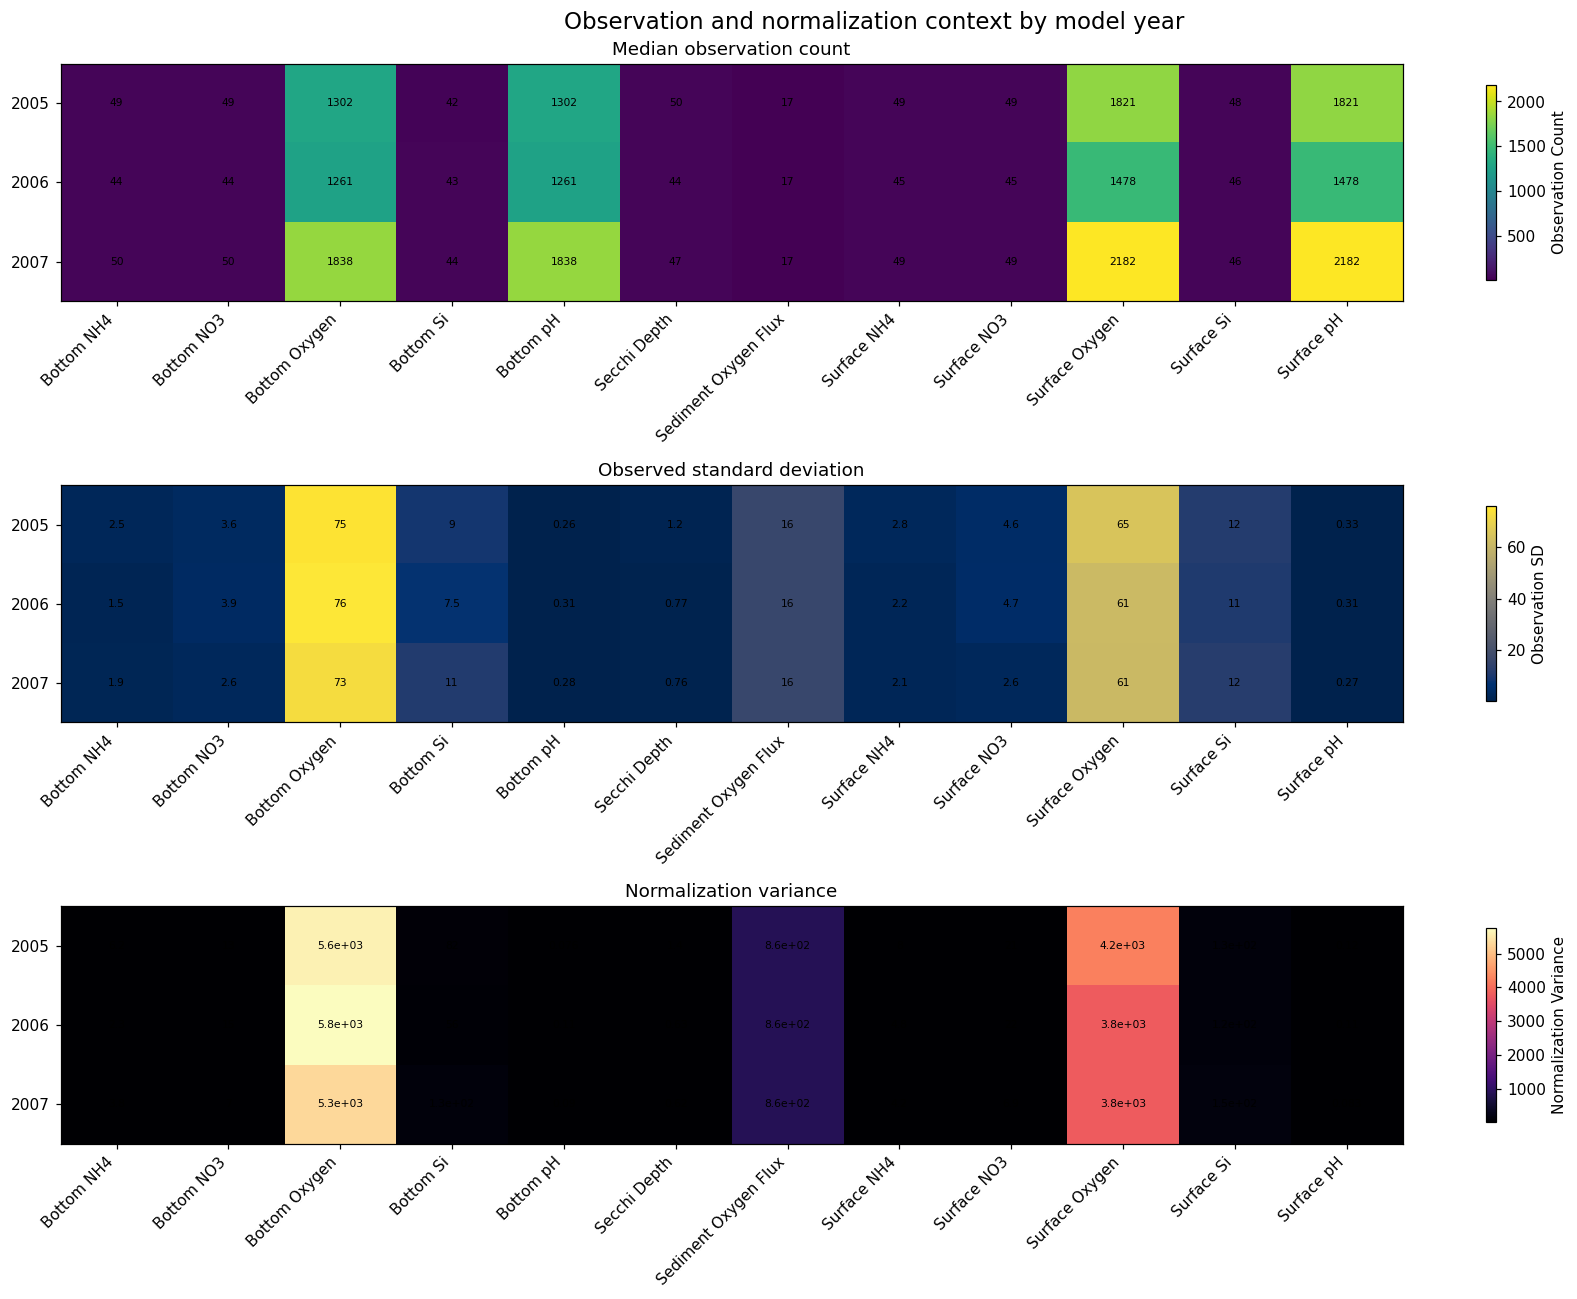

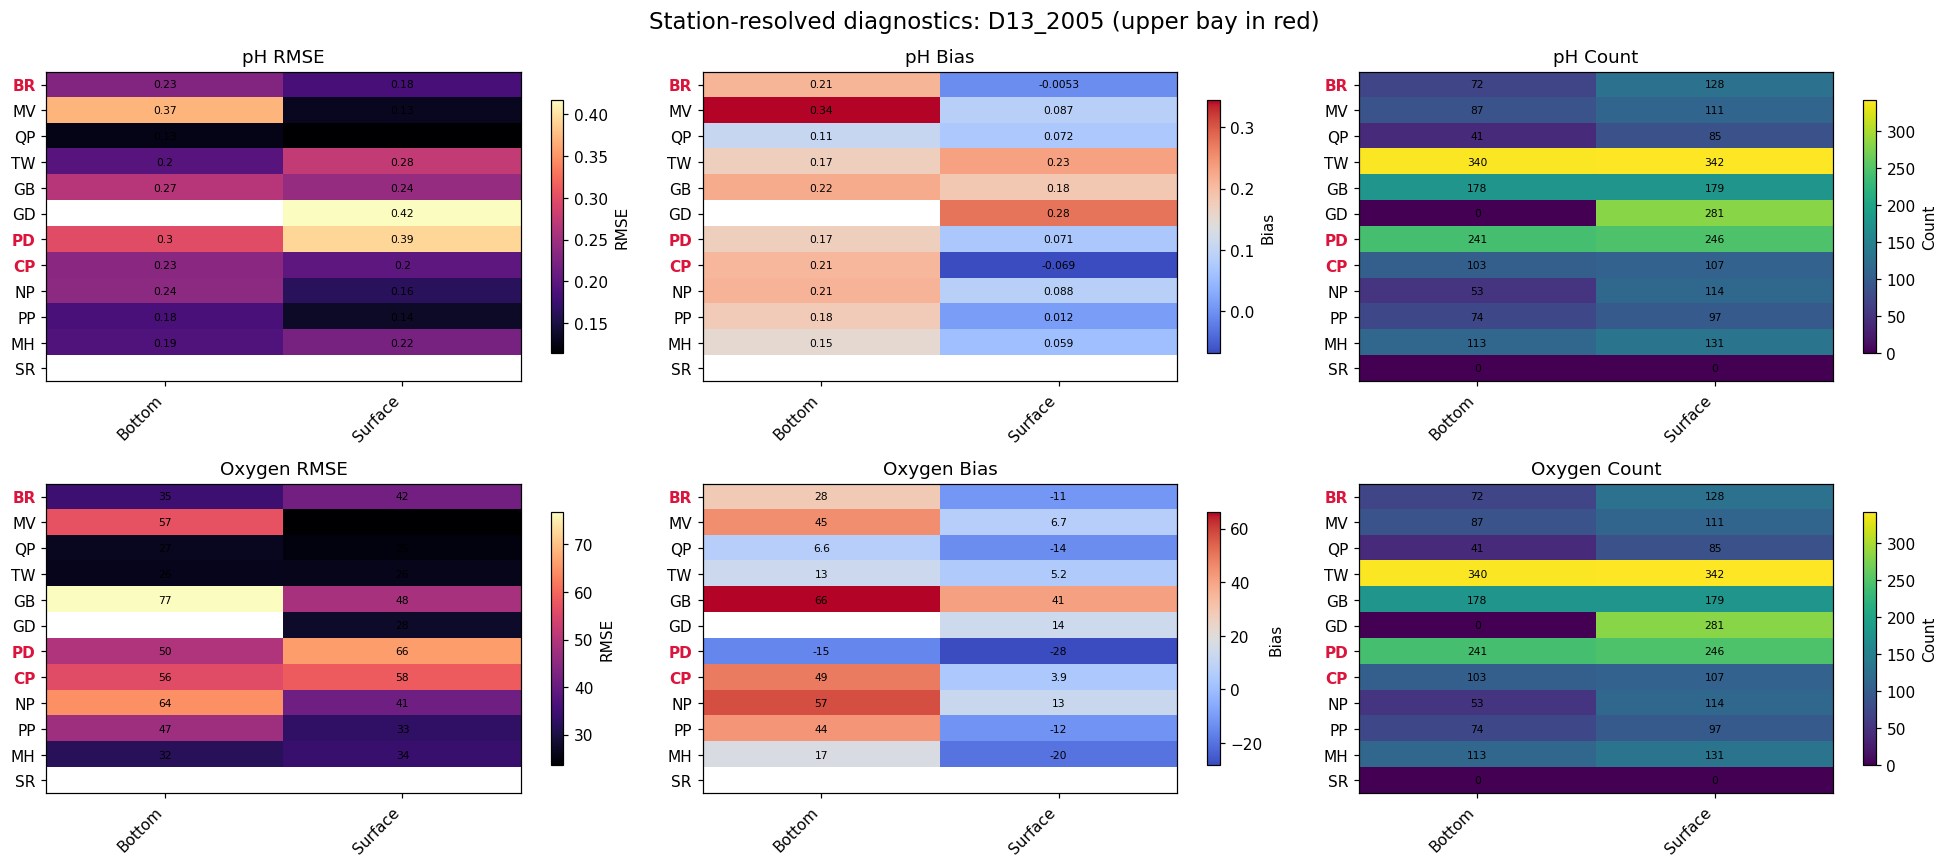

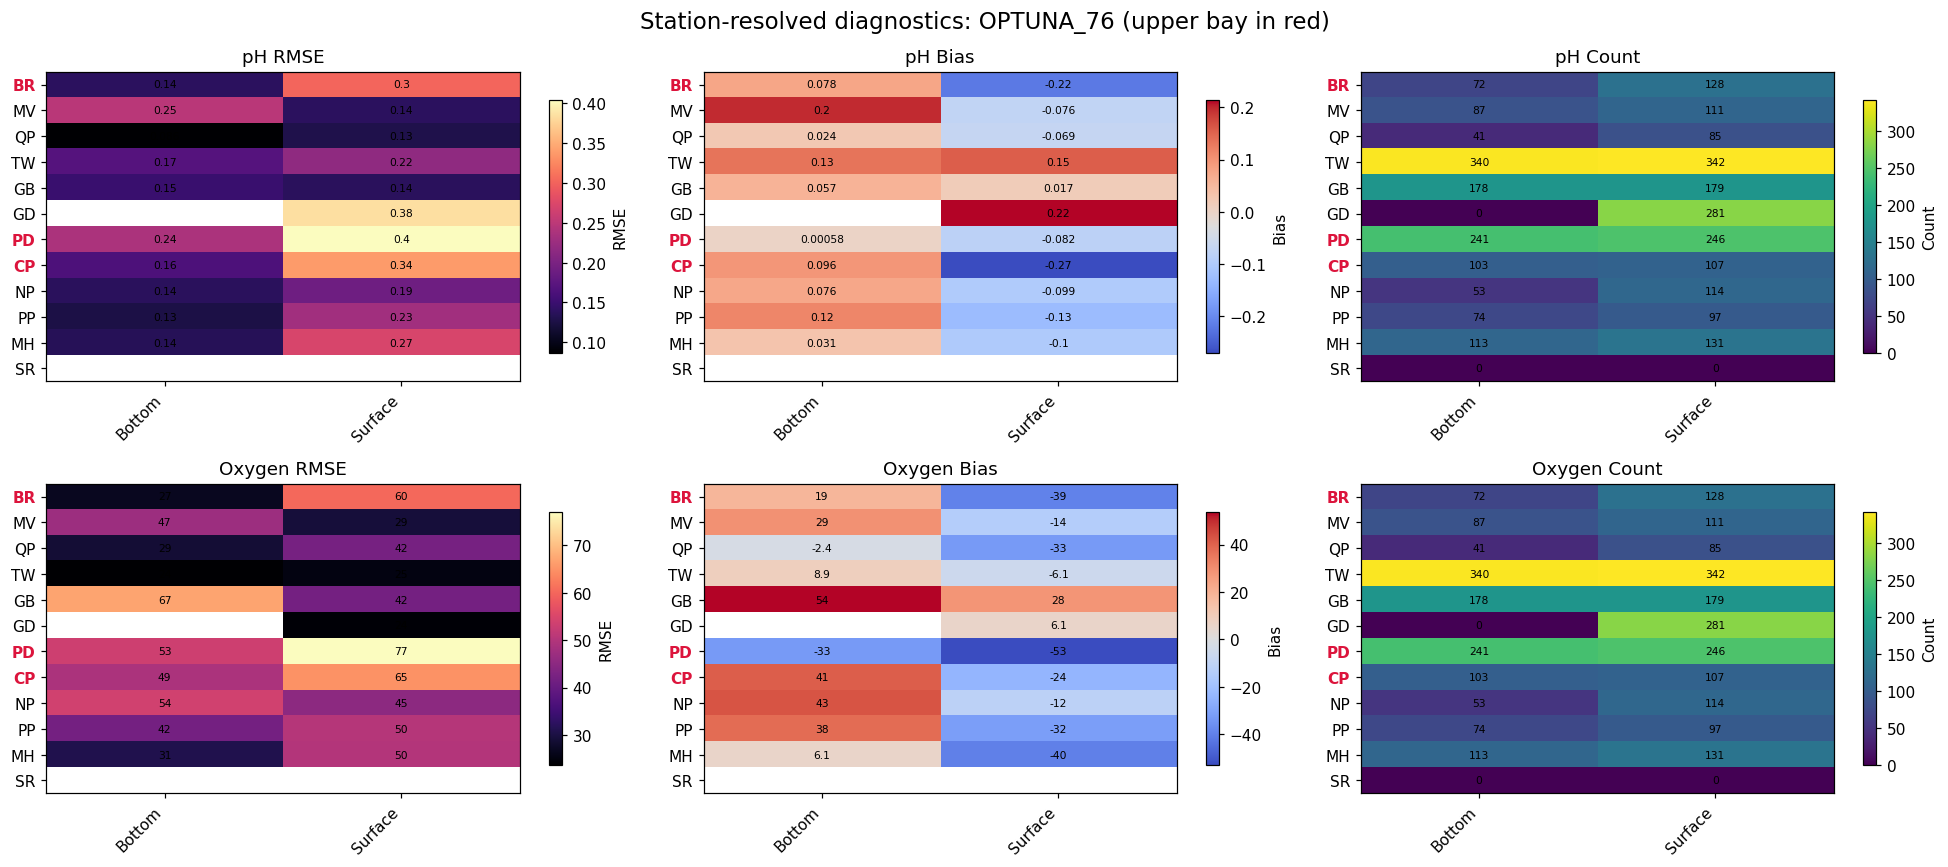

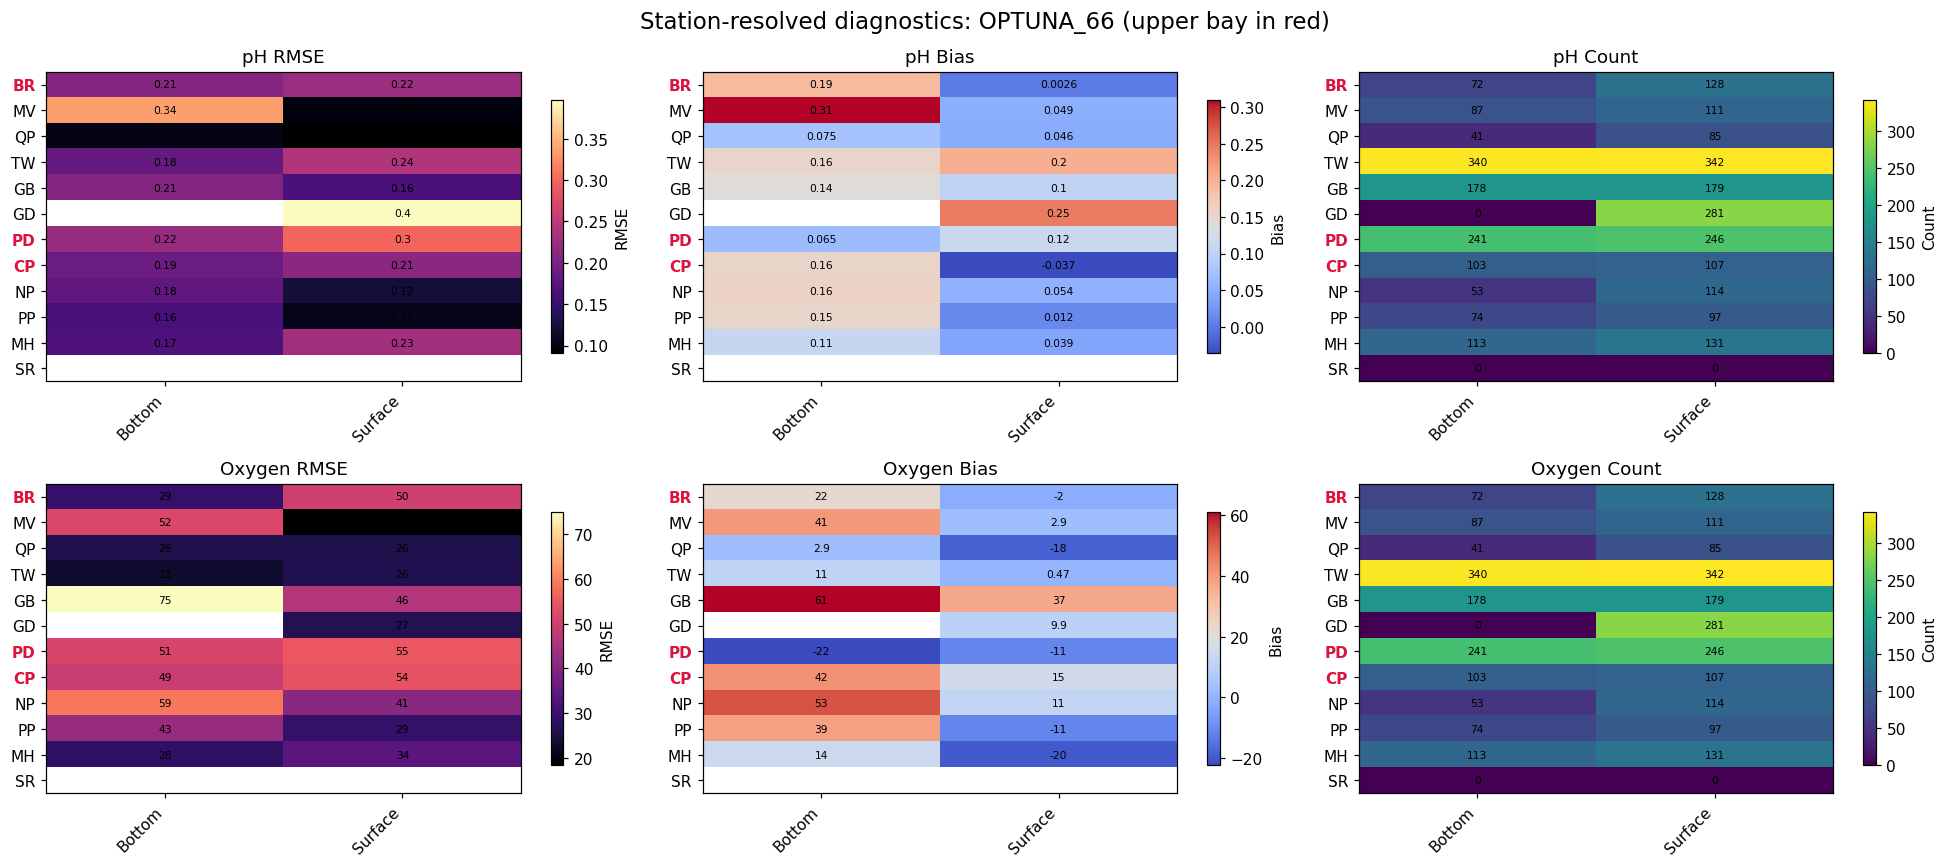

,Run Name,Variable,Station,Depth,Count,RMSE,Bias
0,D13_2005,pH,BR,Surface,128,0.183454,-0.005333
1,D13_2005,pH,BR,Bottom,72,0.227439,0.209970
2,D13_2005,pH,MV,Surface,111,0.132207,0.087228
3,D13_2005,pH,MV,Bottom,87,0.371215,0.344932
4,D13_2005,pH,QP,Surface,85,0.113440,0.072036
5,D13_2005,pH,QP,Bottom,41,0.126817,0.105501
6,D13_2005,pH,TW,Surface,342,0.275924,0.231952
7,D13_2005,pH,TW,Bottom,340,0.195185,0.170433
8,D13_2005,pH,GB,Surface,179,0.242886,0.181787
9,D13_2005,pH,GB,Bottom,178,0.265768,0.221569


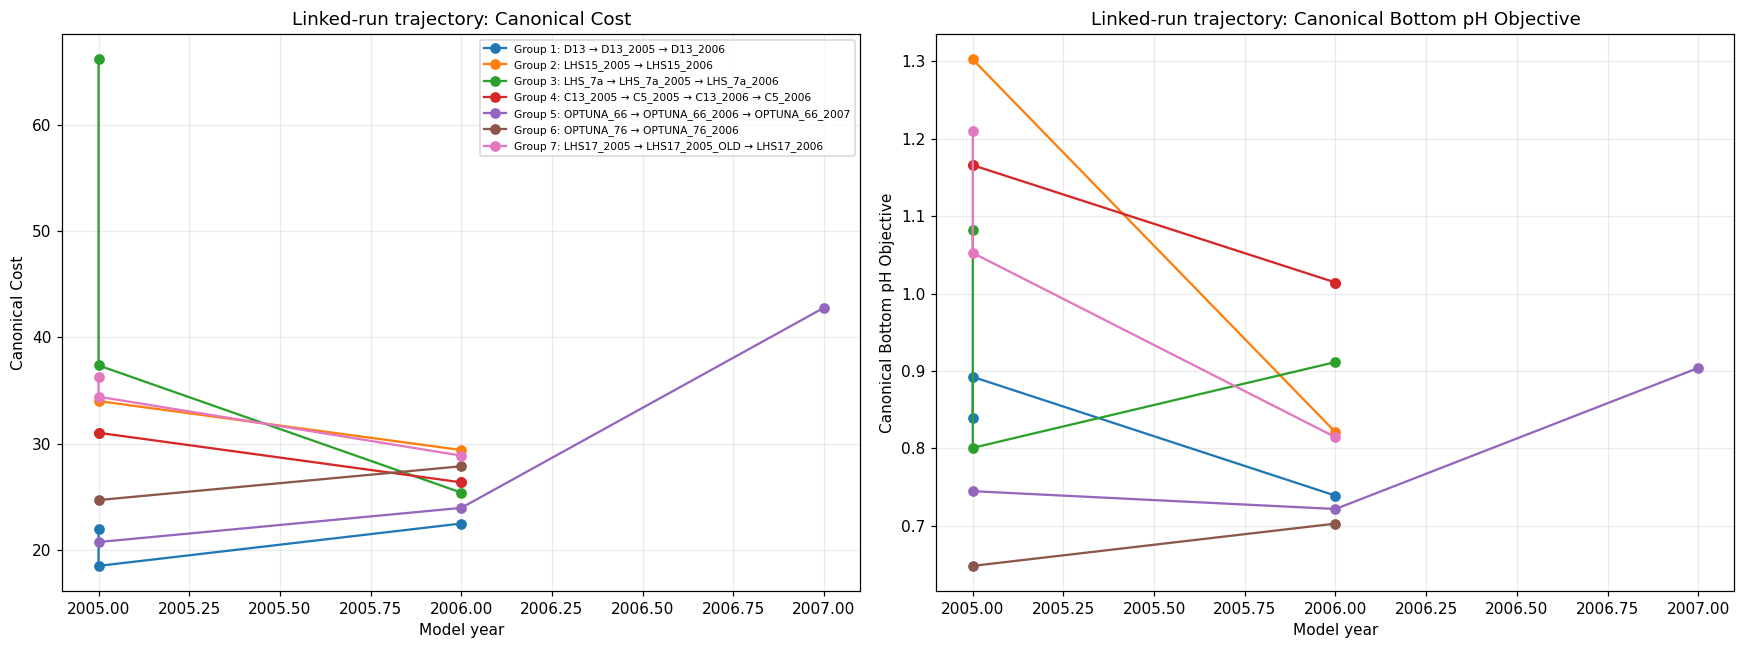

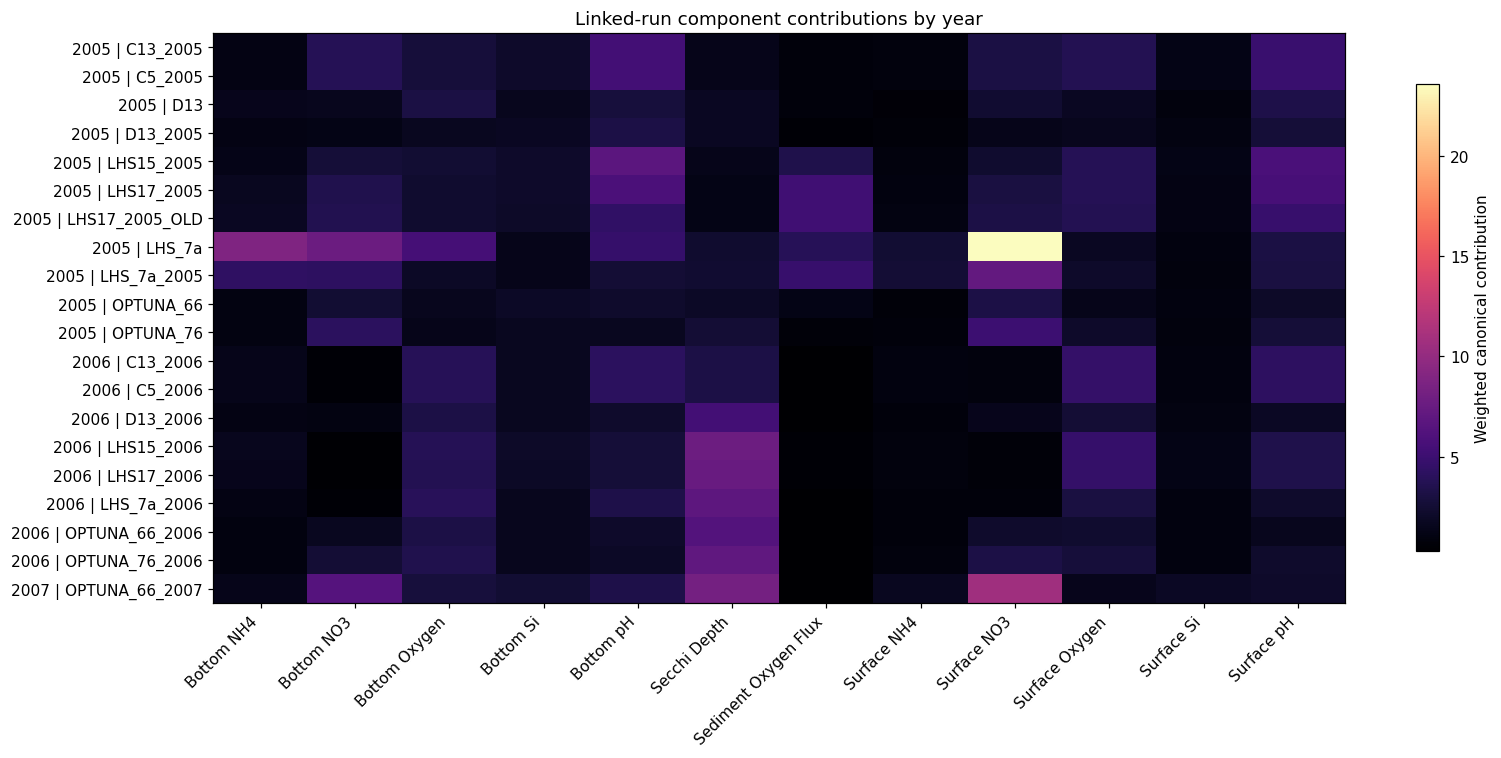

In [11]:
DF_components = DF_refreshed_components.copy()
DF_invalid = DF_components.loc[DF_components["required"] & DF_components["status"].ne("calculated")]
DF_chrp = DF_components.loc[DF_components["source"].eq("CHRP")]
if DATA_LOAD_MODE == "cache":
    DF_linked = pd.read_csv(OUTPUT_PATHS.linked_year_comparisons_file)
    DF_linked_pooled = pd.read_csv(OUTPUT_PATHS.linked_year_components_file)
else:
    DF_linked = cpu.matched_year_comparisons(DF_analysis, objective_columns=objective_columns)
    DF_linked_pooled = cmo.pooled_linked_year_components(
        DF_archive, cmo.load_component_specs(COMPONENTS_FILE), cost_root=COST_DIR
    )
    if DATA_LOAD_MODE == "refresh_and_save":
        cpu.atomic_write_csv(DF_linked, OUTPUT_PATHS.linked_year_comparisons_file, index=False)
        cpu.atomic_write_csv(DF_linked_pooled, OUTPUT_PATHS.linked_year_components_file, index=False)

print("Required components failing 100% model coverage")
display(DF_invalid[["Run Name", "component", "status", "observation_count", "paired_count", "model_coverage"]])
print(f"CHRP diagnostic rows: {len(DF_chrp)} (never included in an objective)")
print(f"Linked-year annual comparisons: {len(DF_linked)}")
print(f"Linked-year pooled component rows: {len(DF_linked_pooled)}")
if not DF_linked.empty:
    display(DF_linked.head(20))

DF_observation_year_context = cplot.observation_year_context(
    DF_components, DF_archive,
    output=(OUTPUT_PATHS.figure_directory / "canonical_observation_year_context.png")
    if SAVE_AUDIT_OUTPUTS else None,
)
station_runs = list(STATION_DIAGNOSTIC_RUNS) or DF_representatives["Run Name"].drop_duplicates().tolist()
DF_station_diagnostics = cplot.station_diagnostics(
    DF_archive, station_runs, cost_root=COST_DIR,
    output_directory=OUTPUT_PATHS.figure_directory if SAVE_AUDIT_OUTPUTS else None,
)
if not DF_station_diagnostics.empty:
    display(DF_station_diagnostics.head(40))
DF_linked_component_trajectories = cplot.linked_run_trajectories(
    DF_analysis, DF_components, objective_columns,
    maximum_groups=MAX_LINKED_TRAJECTORY_GROUPS,
    output_directory=OUTPUT_PATHS.figure_directory if SAVE_AUDIT_OUTPUTS else None,
)
if SAVE_AUDIT_OUTPUTS:
    cpu.atomic_write_csv(DF_observation_year_context, OUTPUT_PATHS.audit_directory / "canonical_observation_year_context.csv", index=False)
    cpu.atomic_write_csv(DF_station_diagnostics, OUTPUT_PATHS.audit_directory / "canonical_station_diagnostics.csv", index=False)

## 9. Continuation recommendations and planning

Continuation sources are ranked from the configured source year using canonical Pareto rank, balanced objective performance, and parameter-space diversity. Existing exact target-year parameter matches are not recommended again.

Planning remains deliberate: place chosen source names in `CONTINUATION_SOURCES_TO_PLAN`, run the notebook in `review`, and manually add the displayed rows to the `MO-BIO Year Transitions` worksheet. The notebook never silently edits the workbook.

,Continuation Priority,Run Name,dstart_year,Pareto Rank,Canonical Cost,Canonical Bottom pH Objective,Balanced Objective Score,Distance from Earlier Suggestions,Diversity Assessment,Parameter Match Group,Existing Target-Year Match,All Tracer Advection Policy Compliant,CACO3,RIVER_SEDIMENT,USE_MOCSY
0,1,OPTUNA_65,2005.0,1,20.792638,0.853359,0.245778,NaN,first suggestion,ffa5e456ec0f,False,True,False,False,False
1,2,D12,2005.0,1,23.127577,0.838984,0.311790,0.222841,moderately distinct,e6e89d76b831,False,False,False,False,False
2,3,OPTUNA_77,2005.0,1,34.225045,0.668543,0.500000,0.088518,similar/redundant,1471ae8fe124,False,True,False,False,False
3,4,OPTUNA_74,2005.0,1,20.529873,0.927192,0.327124,0.036803,similar/redundant,ba8392ecb8c4,False,True,False,False,False
4,5,D18,2005.0,1,26.646333,0.783931,0.370226,0.034416,similar/redundant,c736e7c56364,False,False,False,False,False
5,6,OPTUNA_67,2005.0,1,20.274200,0.996504,0.403166,0.019359,similar/redundant,5cb773476507,False,True,False,False,False
6,7,A4,2005.0,2,26.710562,0.902695,0.518527,0.028816,similar/redundant,91975e67a5b2,False,False,False,False,False
7,8,OPTUNA_75,2005.0,2,20.357811,1.010939,0.423909,0.025836,similar/redundant,ac3fbe8bfd36,False,True,False,False,False
8,9,A1,2005.0,2,28.775114,0.835347,0.509728,0.014971,similar/redundant,aab7128d1c39,False,False,False,False,False
9,10,A3,2005.0,2,28.052962,0.871655,0.528480,0.004444,similar/redundant,212944e02a55,False,False,False,False,False


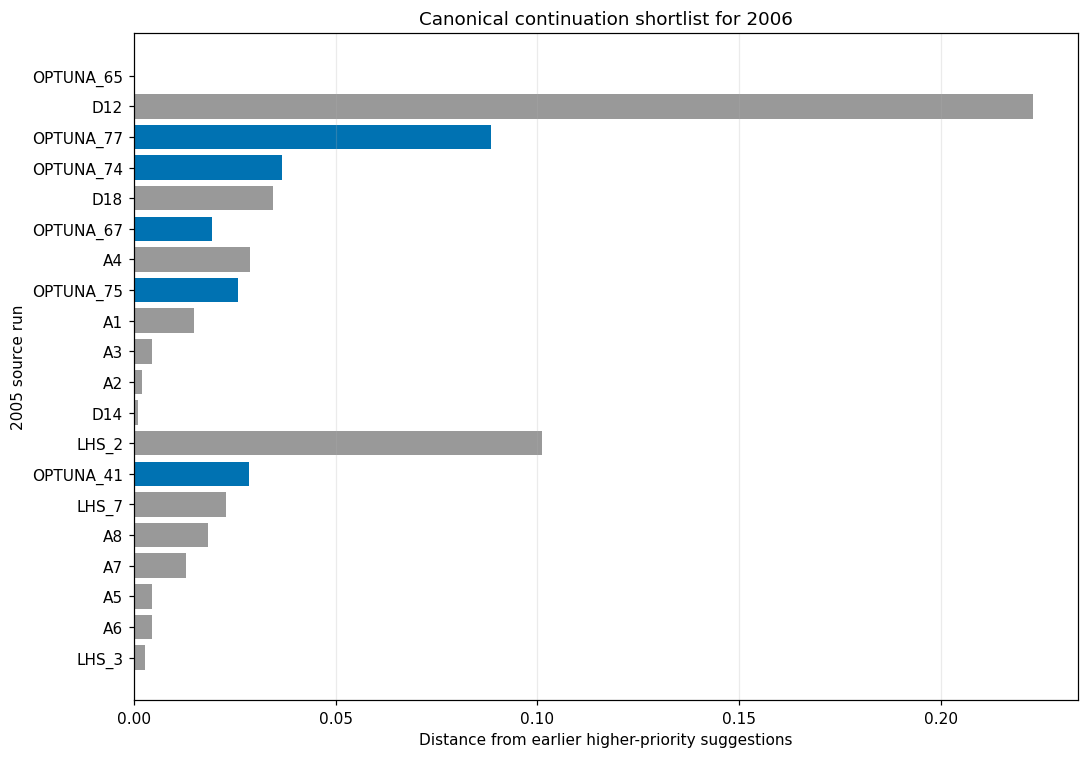

In [12]:
DF_continuation_recommendations = cpu.continuation_recommendations(
    DF_analysis,
    cpu.load_parameter_priors(MATCH_PRIORS_FILE),
    source_year=CONTINUATION_SOURCE_YEAR,
    target_year=CONTINUATION_TARGET_YEAR,
    maximum_pareto_rank=NEAR_PARETO_RANK,
    objective_columns=objective_columns,
)
if not DF_continuation_recommendations.empty:
    source_context = DF_analysis[[
        "Run Name", "All Tracer Advection Policy Compliant", "CACO3",
        "RIVER_SEDIMENT", "USE_MOCSY",
    ]].drop_duplicates("Run Name")
    DF_continuation_recommendations = DF_continuation_recommendations.merge(
        source_context, on="Run Name", how="left", validate="one_to_one"
    )
    display(DF_continuation_recommendations)

    plot = DF_continuation_recommendations.head(25).copy()
    fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * len(plot))))
    colors = np.where(plot["All Tracer Advection Policy Compliant"], "#0072B2", "0.6")
    ax.barh(plot["Run Name"], plot["Distance from Earlier Suggestions"].fillna(0), color=colors)
    ax.invert_yaxis()
    ax.set(xlabel="Distance from earlier higher-priority suggestions",
           ylabel=f"{CONTINUATION_SOURCE_YEAR} source run",
           title=f"Canonical continuation shortlist for {CONTINUATION_TARGET_YEAR}")
    ax.grid(axis="x", alpha=0.25)
    fig.tight_layout()
    if SAVE_AUDIT_OUTPUTS:
        cpu.save_figure(fig, OUTPUT_PATHS.figure_directory / "canonical_continuation_parameter_diversity.png")
    plt.show()
else:
    print("No continuation-eligible source runs meet the configured rules.")

DF_continuation_rows_to_add = cpu.planned_transition_additions(
    CONTINUATION_SOURCES_TO_PLAN,
    action="continuation",
    source_year=CONTINUATION_SOURCE_YEAR,
    target_year=CONTINUATION_TARGET_YEAR,
    archive=DF_analysis,
    existing_plan=DF_year_transition_plan,
)
if not DF_continuation_rows_to_add.empty:
    DF_continuation_rows_to_add["Notes"] = CONTINUATION_LEDGER_TAG
    print(f"Add these rows to the {YEAR_TRANSITION_SHEET!r} worksheet, save Excel, and rerun:")
    display(DF_continuation_rows_to_add)

completed_updates = DF_year_transition_plan.loc[
    DF_year_transition_plan["Target Run"].isin(DF_analysis["Run Name"])
    & DF_year_transition_plan["Action"].eq("continuation")
    & DF_year_transition_plan["Notes"].fillna("").astype(str).str.contains(CONTINUATION_LEDGER_TAG, regex=False)
    & ~DF_year_transition_plan["Status"].isin(["complete", "cancelled"]),
    ["Target Run"],
].copy()
if not completed_updates.empty:
    completed_updates["Field to update"] = "Status"
    completed_updates["New value"] = "complete"
    print("These completed continuation rows need status updates in Excel:")
    display(completed_updates)

if SAVE_AUDIT_OUTPUTS:
    cpu.atomic_write_csv(
        DF_continuation_recommendations,
        OUTPUT_PATHS.audit_directory / "canonical_continuation_recommendations.csv",
        index=False,
    )

## 10. Write continuation inputs

This mode writes only rows already recorded as `planned` in the transition worksheet. Biological advection is deliberately overridden to U3/C4 for every biological tracer. The manifest records that temperature and salinity U3/C4 must be enforced in the separate physical ROMS configuration.

In [13]:
DF_continuation_files = pd.DataFrame()
DF_continuation_manifest = pd.DataFrame()
if RUN_MODE == "write_continuation_inputs":
    if not DF_continuation_rows_to_add.empty:
        raise ValueError(
            f"Record the displayed pending rows in {YEAR_TRANSITION_SHEET!r}, save Excel, and rerun before writing files."
        )
    parameters_to_copy = list(dict.fromkeys([
        *cpu.OPTICS_PARAMETERS,
        *cpu.SEDIMENT_PARAMETERS,
        BIO_NL_TNU2_PARAMETER,
    ]))
    canonical_transition_plan = DF_year_transition_plan.loc[
        DF_year_transition_plan["Notes"].fillna("").astype(str).str.contains(
            CONTINUATION_LEDGER_TAG, regex=False
        )
    ]
    continuation_candidates = cpu.transition_candidate_table(
        canonical_transition_plan,
        DF_analysis,
        action="continuation",
        source_year=CONTINUATION_SOURCE_YEAR,
        target_year=CONTINUATION_TARGET_YEAR,
        parameters_to_copy=parameters_to_copy,
    )
    if continuation_candidates.empty:
        raise ValueError(
            "No planned continuation rows match the configured source and target years."
        )

    # New continuation simulations follow the future candidate policy even
    # when their historical source used another advection scheme.
    continuation_candidates[BIO_ADVECTION_PARAMETER] = CANONICAL_BIO_ADVECTION_CATEGORY
    source_metadata = DF_analysis[[
        "Run Name", "All Tracer Advection Policy Compliant", "CACO3",
        "RIVER_SEDIMENT", "USE_MOCSY",
    ]].rename(columns={
        "Run Name": "Source Run",
        "All Tracer Advection Policy Compliant": "Source All-Tracer U3/C4 Compliant",
        "CACO3": "Source CACO3",
        "RIVER_SEDIMENT": "Source RIVER_SEDIMENT",
        "USE_MOCSY": "Source USE_MOCSY",
    })
    continuation_candidates = continuation_candidates.merge(
        source_metadata, on="Source Run", how="left", validate="many_to_one"
    )
    continuation_candidates["Biological Advection Policy"] = "Upstream3_Centered4 for all biological tracers"
    continuation_candidates["Required Physical Advection Policy"] = "Upstream3_Centered4 for temperature and salinity"

    optics_texts, sediment_texts = cpu.build_candidate_input_texts(
        continuation_candidates,
        optics_template=OPTICS_TEMPLATE,
        sediment_template=SEDIMENT_TEMPLATE,
        optics_parameters=cpu.OPTICS_PARAMETERS,
        sediment_parameters=cpu.SEDIMENT_PARAMETERS,
        fixed_values={},
        biological_tnu2_parameter=BIO_NL_TNU2_PARAMETER,
        biological_advection_parameter=BIO_ADVECTION_PARAMETER,
        biological_advection_schemes=BIO_ADVECTION_SCHEMES,
        advection_input_codes=ADVECTION_INPUT_CODES,
        biological_tracer_count=BIOLOGICAL_TRACER_COUNT,
        remote_sediment_directory=REMOTE_SEDIMENT_DIRECTORY,
    )
    DF_continuation_advection_validation = cpu.validate_biological_advection_texts(
        optics_texts, horizontal_code=ADVECTION_INPUT_CODES["Upstream3"],
        vertical_code=ADVECTION_INPUT_CODES["Centered4"],
        biological_tracer_count=BIOLOGICAL_TRACER_COUNT,
    )
    display(DF_continuation_advection_validation)
    output_directory = OUTPUT_PATHS.continuation_input_directory(CONTINUATION_TARGET_YEAR)
    DF_continuation_files = cpu.write_candidate_input_files(
        optics_texts, sediment_texts, output_directory,
        overwrite=OVERWRITE_CONTINUATION_FILES,
    )
    DF_continuation_manifest = cpu.build_transition_manifest(
        continuation_candidates, DF_continuation_files, action="continuation"
    )
    manifest_file = OUTPUT_PATHS.continuation_manifest_file(CONTINUATION_TARGET_YEAR)
    cpu.append_transition_manifest(
        DF_continuation_manifest, manifest_file,
        overwrite=OVERWRITE_CONTINUATION_FILES,
    )
    display(DF_continuation_files)
    print(f"Continuation manifest: {manifest_file}")
    print(f"Update written targets to Status='inputs_written' in {YEAR_TRANSITION_SHEET!r}.")

## 11. Search space and study safety

Review mode stops here. Action modes load only the canonical database and enforce objective/search-space compatibility.

In [14]:
study = None
DF_historical_import = pd.DataFrame()
priors, numeric_bounds, categorical_choices = cmo.canonical_search_space(PARAMETER_PRIORS_FILE)
fingerprint = cmo.canonical_study_fingerprint(
    numeric_bounds, categorical_choices,
    components_file=COMPONENTS_FILE, seed=RANDOM_SEED,
)
print("Active numeric parameters:", list(numeric_bounds))
print("Active categorical parameters:", list(categorical_choices))

study_modes = {"prepare_study", "generate_candidates", "register_results", "write_inputs"}
if RUN_MODE == "review" and OUTPUT_PATHS.study_database.is_file():
    try:
        import optuna
        study = optuna.load_study(
            study_name=STUDY_NAME, storage=f"sqlite:///{OUTPUT_PATHS.study_database}"
        )
        print(f"Existing canonical study opened for diagnostics: trials={len(study.trials)}")
    except (ImportError, KeyError, RuntimeError, ValueError) as error:
        print(f"Existing-study diagnostics unavailable: {error}")
if RUN_MODE in study_modes:
    import optuna
    study, priors, numeric_bounds, categorical_choices, fingerprint = cmo.create_or_load_canonical_study(
        output_paths=OUTPUT_PATHS,
        priors_file=PARAMETER_PRIORS_FILE,
        components_file=COMPONENTS_FILE,
        study_name=STUDY_NAME,
        seed=RANDOM_SEED,
    )
    print(f"Canonical study loaded: {study.study_name}; trials={len(study.trials)}")

Active numeric parameters: ['reg1', 'reg2', 'beta1', 'beta2', 'akz1', 'akz2', 'akno3s1', 'akno3s2', 'bgamma4', 'bgamma5', 'bgamma5s', 'bgamma6', 'wsd']
Active categorical parameters: []


/Users/akbaskind/Documents/Python Scripts/ROMS/ROMS-COSiNE-NB_Tuning/candidate_parameter_utils.py:2679: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(
[I 2026-10-04 14:43:29,525] A new study created in RDB with name: model_calibration_bio_canonical_v1


Canonical study loaded: model_calibration_bio_canonical_v1; trials=0


## 12. Prepare study and import completed historical runs

In [15]:
if RUN_MODE == "prepare_study":
    DF_historical_import = cmo.prepare_study(
        DF_archive,
        output_paths=OUTPUT_PATHS,
        priors_file=PARAMETER_PRIORS_FILE,
        components_file=COMPONENTS_FILE,
        corrections_file=LEGACY_CORRECTIONS_FILE,
        study_name=STUDY_NAME,
        seed=RANDOM_SEED,
    )
    display(DF_historical_import["Import Status"].value_counts().rename("Count").to_frame())
    study, _, _, _, _ = cmo.create_or_load_canonical_study(
        output_paths=OUTPUT_PATHS, priors_file=PARAMETER_PRIORS_FILE,
        components_file=COMPONENTS_FILE, study_name=STUDY_NAME, seed=RANDOM_SEED,
    )

/Users/akbaskind/Documents/Python Scripts/ROMS/ROMS-COSiNE-NB_Tuning/candidate_parameter_utils.py:2679: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(
[I 2026-10-04 14:43:29,590] Using an existing study with name 'model_calibration_bio_canonical_v1' instead of creating a new one.


,Count
Import Status,
added,124


/Users/akbaskind/Documents/Python Scripts/ROMS/ROMS-COSiNE-NB_Tuning/candidate_parameter_utils.py:2679: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(
[I 2026-10-04 14:43:32,558] Using an existing study with name 'model_calibration_bio_canonical_v1' instead of creating a new one.


## 13. Generate canonical candidate trials

In [16]:
DF_candidates = pd.DataFrame()
if RUN_MODE == "generate_candidates":
    if not study.user_attrs.get("Historical Import Completed", False):
        raise ValueError("Run prepare_study before generating candidates")
    if CANDIDATE_INITIALIZATION_POLICY == "common_anchor":
        anchor = DF_analysis.loc[DF_analysis["Run Name"].eq(CANDIDATE_INITIALIZATION_RUN)]
        if len(anchor) != 1:
            raise ValueError("The requested initialization anchor is not uniquely available")
        anchor_year = pd.to_numeric(anchor.iloc[0].get("dstart_year"), errors="coerce")
        if not np.isfinite(anchor_year) or int(anchor_year) >= int(CANDIDATE_TARGET_YEAR):
            raise ValueError("The initialization anchor must come from an earlier model year")

    context = {
        "Candidate Target Year": int(CANDIDATE_TARGET_YEAR),
        "Initialization Policy": CANDIDATE_INITIALIZATION_POLICY,
        "Initialization Source Run": CANDIDATE_INITIALIZATION_RUN,
        "Candidate Batch ID": CANDIDATE_BATCH_ID,
        "Biological Advection Policy": "U3 horizontal / C4 vertical for all 15 biological tracers",
        "Required Physical Advection Policy": "U3 horizontal / C4 vertical for temperature and salinity",
    }
    proposed = cpu.ask_candidate_trials(
        study,
        numeric_bounds=numeric_bounds,
        categorical_choices=categorical_choices,
        count=N_CANDIDATES,
        run_name_prefix="OPTUNA_BIO_CANONICAL_",
        run_name_suffix="" if CANDIDATE_TARGET_YEAR == 2005 else f"_{CANDIDATE_TARGET_YEAR}",
        objective_version=cmo.OBJECTIVE_VERSION,
        trial_user_attrs=context,
    )
    baseline_rows = DF_analysis.loc[DF_analysis["Run Name"].eq(BASELINE_RUN_NAME)]
    if len(baseline_rows) != 1:
        raise ValueError(f"Expected one baseline {BASELINE_RUN_NAME!r}; found {len(baseline_rows)}")
    baseline = baseline_rows.iloc[0]
    template_parameters = [*cpu.OPTICS_PARAMETERS, *cpu.SEDIMENT_PARAMETERS,
                           BIO_NL_TNU2_PARAMETER, BIO_ADVECTION_PARAMETER]
    fixed_values = {
        parameter: (str(baseline[parameter]) if parameter == BIO_ADVECTION_PARAMETER else float(baseline[parameter]))
        for parameter in template_parameters
        if parameter in baseline.index and pd.notna(baseline[parameter]) and parameter not in proposed.columns
    }
    for row in priors.loc[priors["decision"].eq("fixed")].itertuples(index=False):
        fixed_values[row.parameter] = cpu.parse_prior_fixed_value(row)
    # Canonical candidates never inherit the A4/A4 baseline advection.
    fixed_values[BIO_ADVECTION_PARAMETER] = CANONICAL_BIO_ADVECTION_CATEGORY
    DF_candidates = cpu.build_complete_candidate_summary(
        proposed,
        study_name=STUDY_NAME,
        objective_version=cmo.OBJECTIVE_VERSION,
        search_space_fingerprint=fingerprint,
        parameter_priors_file=PARAMETER_PRIORS_FILE,
        baseline_run_name=BASELINE_RUN_NAME,
        sampler_name=type(study.sampler).__name__,
        fixed_values=fixed_values,
        priors=priors,
        candidate_metadata=context,
    )
    cpu.append_candidate_summary(DF_candidates, OUTPUT_PATHS.candidate_summary_file)
    display(DF_candidates)
    print(f"Candidate history: {OUTPUT_PATHS.candidate_summary_file}")

## 14. Register completed canonical results

In [17]:
DF_registration = pd.DataFrame()
if RUN_MODE == "register_results":
    DF_registration = cpu.synchronize_running_trials(
        study,
        DF_analysis,
        objective_columns=objective_columns,
        run_map=None,
        study_name=STUDY_NAME,
        commit=True,
    )
    display(DF_registration if not DF_registration.empty else pd.DataFrame({"Status": ["No RUNNING trials"]}))

## 15. Write ROMS inputs for RUNNING canonical trials

In [18]:
DF_written_files = pd.DataFrame()
if RUN_MODE == "write_inputs":
    running = [trial for trial in study.trials if trial.state == optuna.trial.TrialState.RUNNING]
    if not running:
        raise ValueError("No RUNNING canonical trials are available")
    trial_candidates = pd.DataFrame([
        {"Run Name": trial.user_attrs.get("Run Name"), "Trial Number": trial.number, **trial.params}
        for trial in running
    ])
    baseline_rows = DF_analysis.loc[DF_analysis["Run Name"].eq(BASELINE_RUN_NAME)]
    if len(baseline_rows) != 1:
        raise ValueError(f"Expected one baseline {BASELINE_RUN_NAME!r}; found {len(baseline_rows)}")
    baseline = baseline_rows.iloc[0]
    template_parameters = [*cpu.OPTICS_PARAMETERS, *cpu.SEDIMENT_PARAMETERS,
                           BIO_NL_TNU2_PARAMETER, BIO_ADVECTION_PARAMETER]
    fixed_values = {
        parameter: (str(baseline[parameter]) if parameter == BIO_ADVECTION_PARAMETER else float(baseline[parameter]))
        for parameter in template_parameters
        if parameter in baseline.index and pd.notna(baseline[parameter]) and parameter not in trial_candidates.columns
    }
    for row in priors.loc[priors["decision"].eq("fixed")].itertuples(index=False):
        fixed_values[row.parameter] = cpu.parse_prior_fixed_value(row)
    # Reassert the canonical policy when reconstructing inputs from RUNNING trials.
    fixed_values[BIO_ADVECTION_PARAMETER] = CANONICAL_BIO_ADVECTION_CATEGORY
    optics_texts, sediment_texts = cpu.build_candidate_input_texts(
        trial_candidates,
        optics_template=OPTICS_TEMPLATE,
        sediment_template=SEDIMENT_TEMPLATE,
        optics_parameters=cpu.OPTICS_PARAMETERS,
        sediment_parameters=cpu.SEDIMENT_PARAMETERS,
        fixed_values=fixed_values,
        biological_tnu2_parameter=BIO_NL_TNU2_PARAMETER,
        biological_advection_parameter=BIO_ADVECTION_PARAMETER,
        biological_advection_schemes=BIO_ADVECTION_SCHEMES,
        advection_input_codes=ADVECTION_INPUT_CODES,
        biological_tracer_count=BIOLOGICAL_TRACER_COUNT,
        remote_sediment_directory=REMOTE_SEDIMENT_DIRECTORY,
    )
    DF_input_advection_validation = cpu.validate_biological_advection_texts(
        optics_texts, horizontal_code=ADVECTION_INPUT_CODES["Upstream3"],
        vertical_code=ADVECTION_INPUT_CODES["Centered4"],
        biological_tracer_count=BIOLOGICAL_TRACER_COUNT,
    )
    display(DF_input_advection_validation)
    DF_written_files = cpu.write_candidate_input_files(
        optics_texts, sediment_texts, OUTPUT_PATHS.candidate_input_directory,
        overwrite=OVERWRITE_CANDIDATE_FILES,
    )
    display(DF_written_files)

## 16. Study learning, provenance, and next action

When a canonical study exists, review mode loads it for diagnostics without creating trials. The figures summarize trial states, cumulative objective progress, Pareto hypervolume, and the TPE promising-versus-less-promising distributions.

,Trials
Origin,
Historical archive,105
Previous optimizer,19


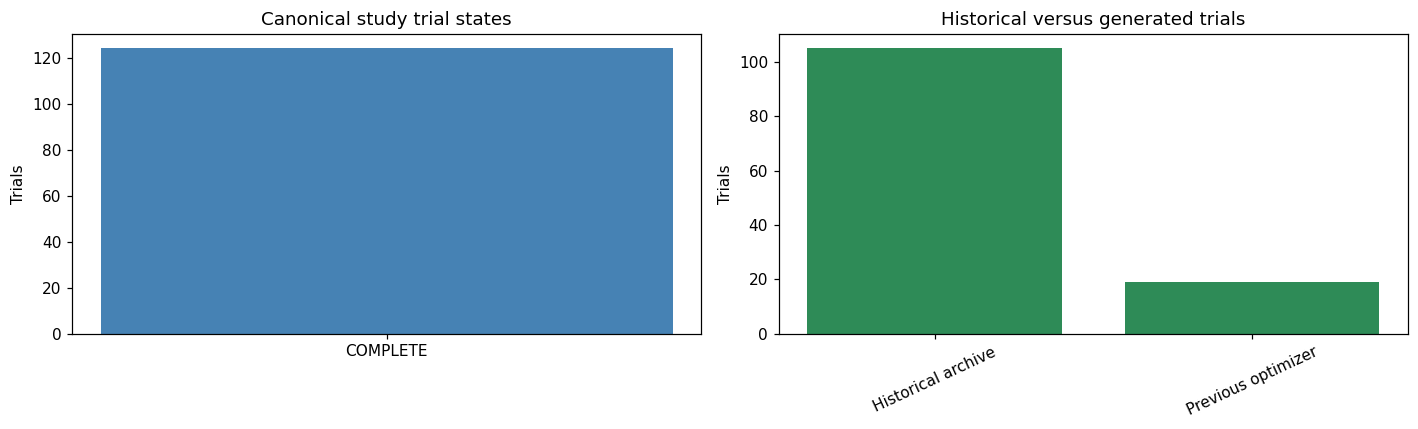

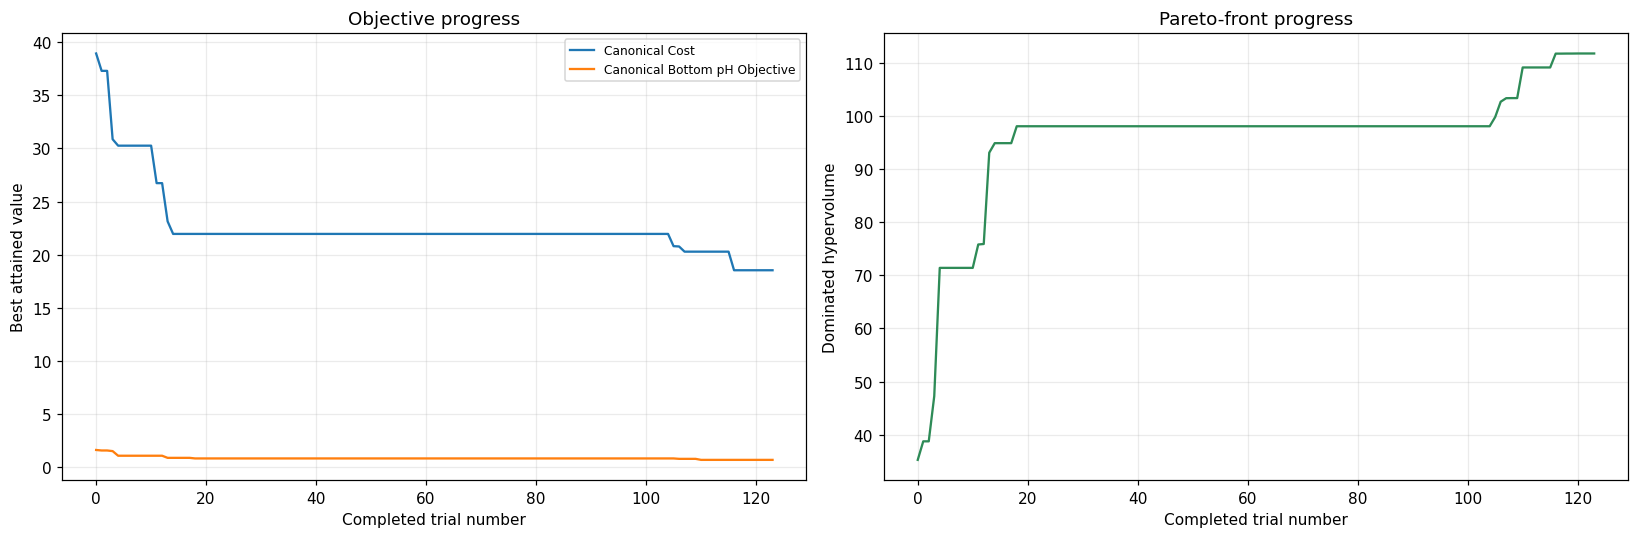

,Trial Number,Best Canonical Cost,Best Canonical Bottom pH Objective,Pareto Hypervolume,Origin
104,104,21.946047,0.783931,98.020220,Previous optimizer
105,105,20.792638,0.783931,99.754702,Previous optimizer
106,106,20.762798,0.744813,102.630489,Previous optimizer
107,107,20.274200,0.744813,103.295297,Previous optimizer
108,108,20.274200,0.744813,103.311441,Previous optimizer
109,109,20.274200,0.744813,103.311441,Previous optimizer
110,110,20.274200,0.648309,109.073148,Previous optimizer
111,111,20.274200,0.648309,109.073148,Previous optimizer
112,112,20.274200,0.648309,109.073148,Previous optimizer
113,113,20.274200,0.648309,109.073148,Previous optimizer


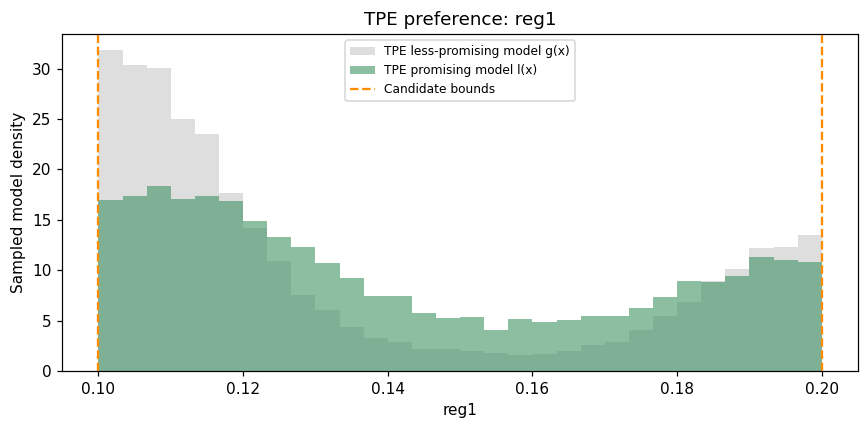

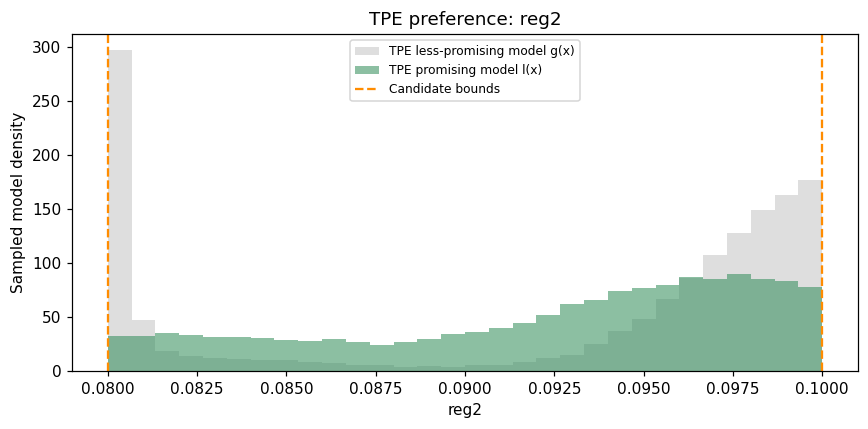

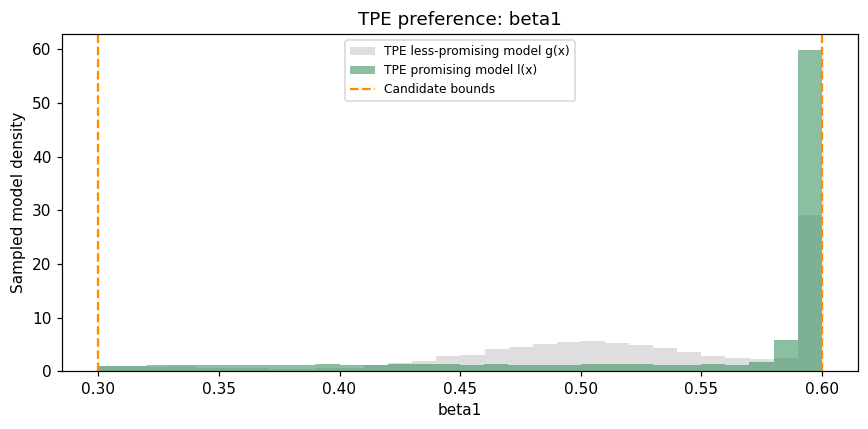

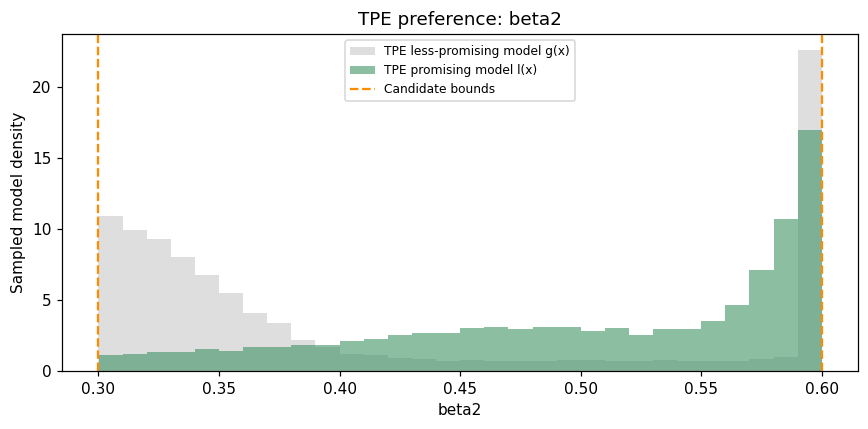

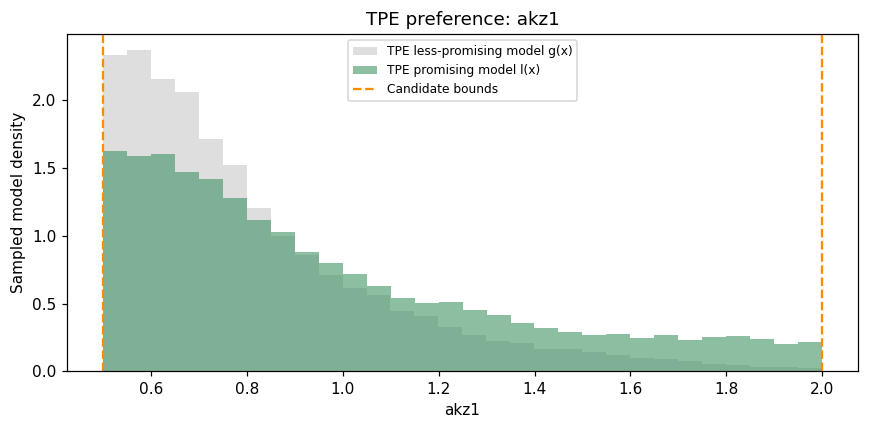

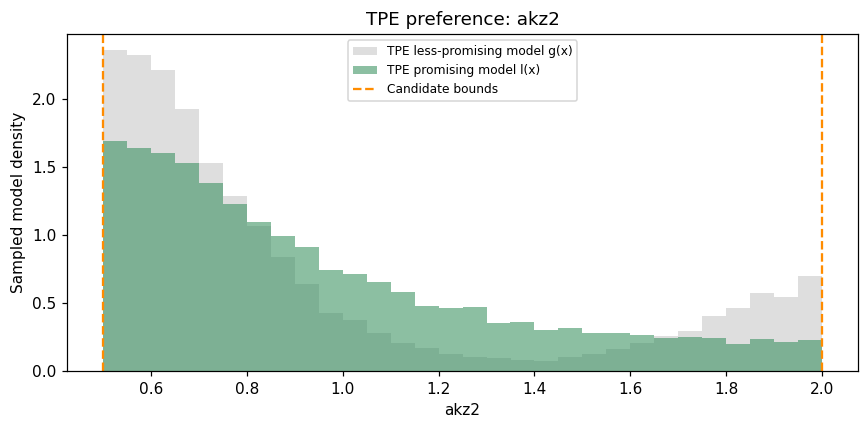

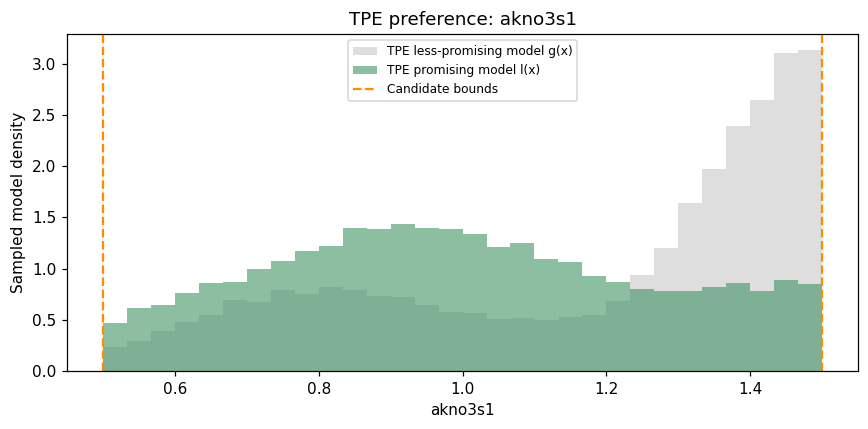

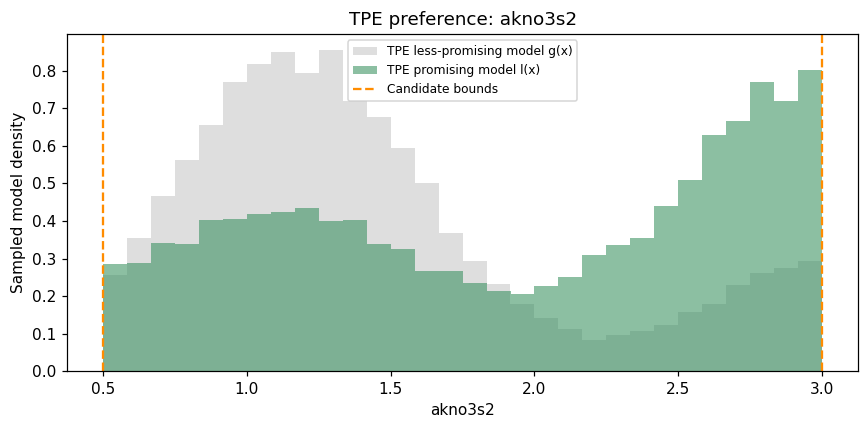

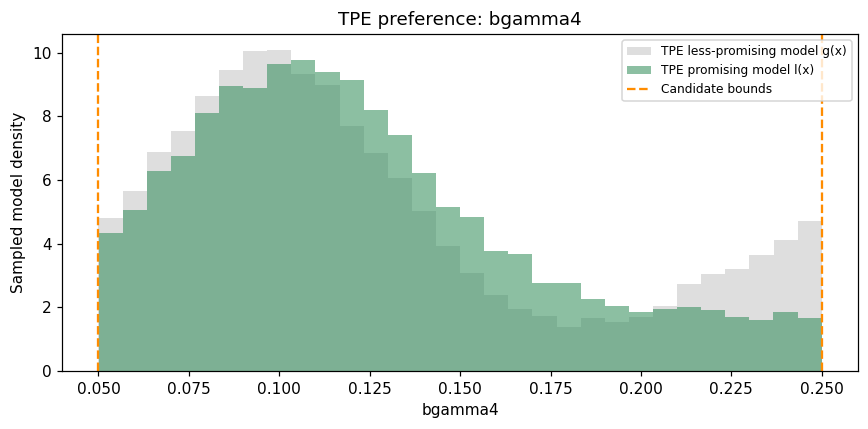

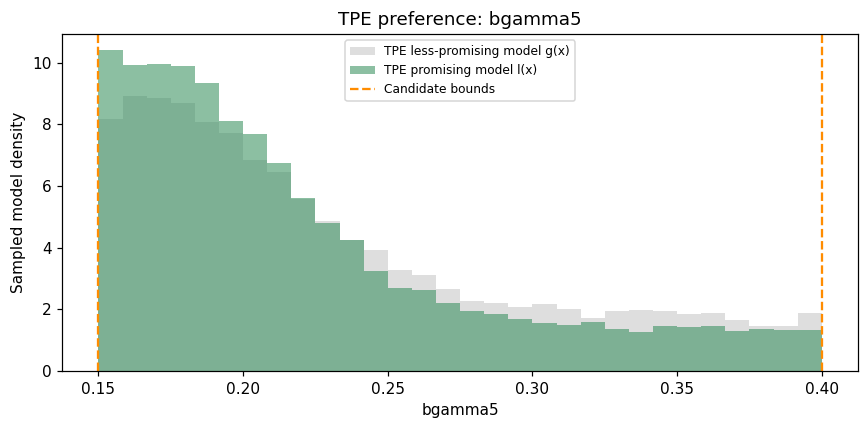

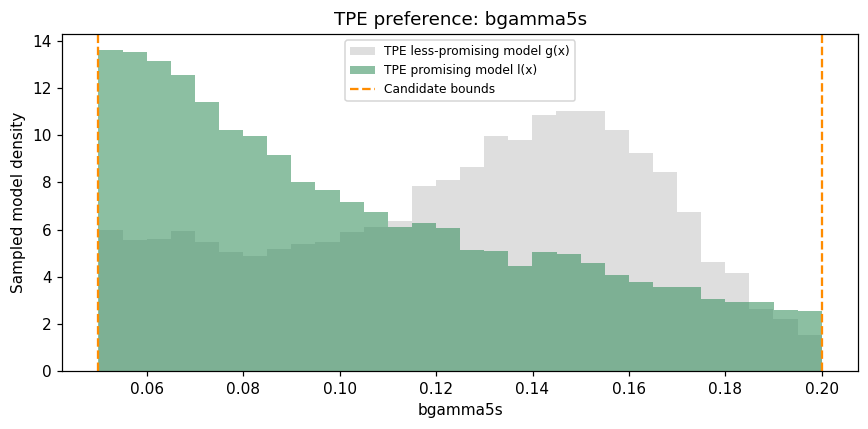

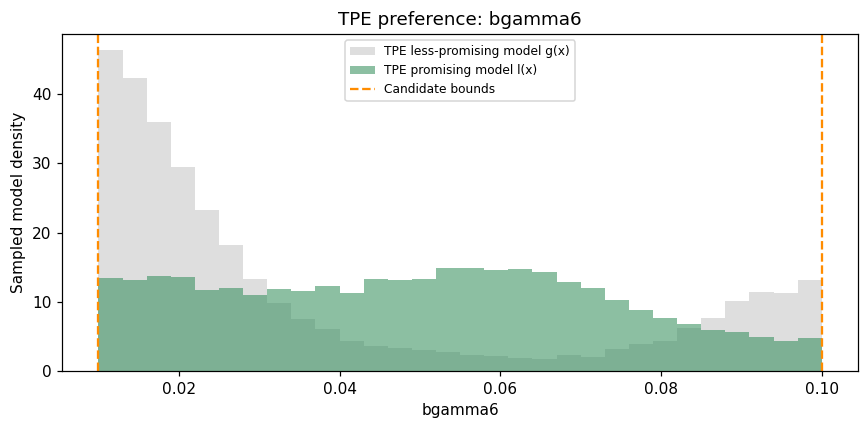

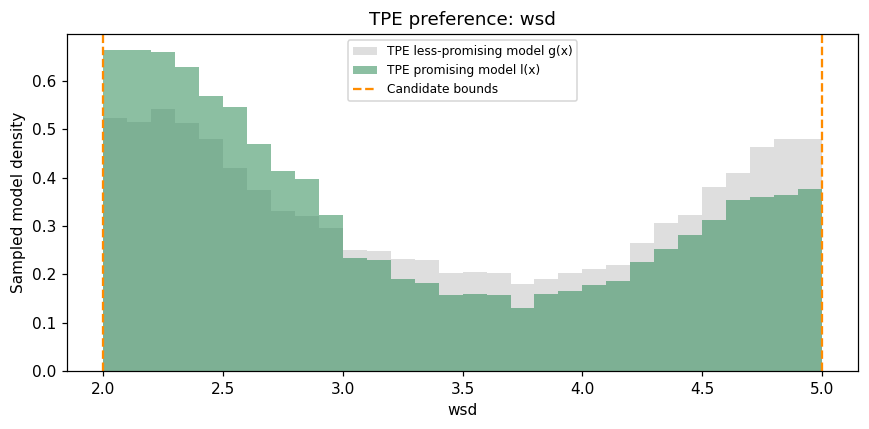

TPE diagnostic: metadata


,Optuna version,Usable trials,Promising trial count,Less-promising trial count,Promising trial numbers,Less-promising trial numbers,Private API
0,4.9.0,124,13,111,"[13, 14, 18, 105, 106, 107, 108, 110, 111, 116...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 15,...",True


Current mode: prepare_study
Canonical output root: /Users/akbaskind/Desktop/Optimization/MO-BIO-CANONICAL
Legacy MO-BIO and PHYS remain untouched.
Return RUN_MODE to 'review' after every action.


In [19]:
if study is not None:
    provenance = cpu.trial_provenance_table(study, DF_analysis)
    cpu.atomic_write_csv(provenance, OUTPUT_PATHS.trial_provenance_file, index=False)
    display(provenance["Origin"].fillna("Unknown").value_counts().rename("Trials").to_frame())
    DF_optimization_progress = cplot.optimization_progress(
        study, objective_columns,
        output_directory=OUTPUT_PATHS.figure_directory if SAVE_AUDIT_OUTPUTS else None,
    )
    if not DF_optimization_progress.empty:
        display(DF_optimization_progress.tail(20))
    TPE_DIAGNOSTIC_TABLES = cplot.tpe_preferences(
        study, study.sampler, numeric_bounds, categorical_choices, seed=RANDOM_SEED,
        output_directory=OUTPUT_PATHS.figure_directory if SAVE_AUDIT_OUTPUTS else None,
    )
    for diagnostic_name, diagnostic_table in TPE_DIAGNOSTIC_TABLES.items():
        print(f"TPE diagnostic: {diagnostic_name}")
        display(diagnostic_table)

print(f"Current mode: {RUN_MODE}")
print(f"Canonical output root: {OUTPUT_ROOT}")
print("Legacy MO-BIO and PHYS remain untouched.")
print("Return RUN_MODE to 'review' after every action.")